<a href="https://colab.research.google.com/github/jenelaineDC/DSML-PROJECTS/blob/main/Online%20Retail/Online_Retail_Analytics_K_Means_Clustering_%26_Apriori.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### BACKGROUND

In today’s data-driven economy, small and mid-sized online retailers often face challenges leveraging customer and transaction data to make informed marketing and operational decisions. Understanding customer value, purchasing behavior, and product affinities is crucial for improving retention, driving growth, and optimizing marketing spend.

This project utilizes the Online Retail II dataset, which contains transactional records from a UK-based non-store retailer specializing in unique all-occasion giftware (December 2009–December 2011). Many of the customers are wholesalers, making it essential to capture both individual and bulk-buying behavior.

By applying advanced customer analytics, predictive modeling, and recommendation techniques, this project demonstrates how data science can uncover actionable insights to guide customer segmentation, lifetime value estimation, and personalized recommendations.


### PROJECT GOAL
The main goals of this project are to:
1. **Estimate Customer Lifetime Value (CLV)**
Model future customer monetary contribution using probabilistic and machine-learning approaches.

2. **Model Customer Activity / Survival
Estimate** the probability that a customer is still “alive” (active) using BG/NBD so we can distinguish dormant from active customers.

3. **Segment Customers Based on Behavioral Patterns**
Use clustering to identify actionable customer groups for targeted marketing and retention.

4. **Build a Product Recommendation System**
Develop a hybrid recommender (association mining + content similarity) to support cross-sell and personalization.

5. **Produce Actionable Business Insights**
Translate model outputs into marketing, CRM, and merchandising recommendations.

### SCOPE AND LIMITATION

**The project will:**
- Use the Online Retail II dataset (2009–2011), focusing only on the variables provided.
- Analytical methods include: BG/NBD (frequency + probability-alive), Gamma-Gamma (monetary modeling), XGBoost (hybrid CLV), K-Means + PCA (segmentation & visualization), and FP-Growth + TF-IDF (hybrid recommendations).


**The project will not:**
- Incorporate external data sources such as competitor activity or macroeconomic conditions.
- Generalize findings beyond this specific retailer, as results are limited to a single dataset.
- Deploy models into production; instead, it will focus on generating insights and analytical frameworks for potential business use.
- Capture all product categories or customer behaviors, since the dataset is time-bound and may not fully represent long-term patterns.

### EXECUTIVE SUMMARY

#### SET-UP

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
%cd /content/drive/MyDrive/DSML PROJECTS/Online Retail

/content/drive/MyDrive/DSML PROJECTS/Online Retail


In [4]:
!pip install lifetimes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 584.2/584.2 kB 9.0 MB/s eta 0:00:00


In [5]:
# for operational packages
import pandas as pd
import numpy as np

# for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# for column display
pd.set_option('display.max_columns', None)

# for Customer Segmentation
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.decomposition import PCA

# for Regressor Model
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# for BG/NBD and Gamma-gamma model
from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.utils import calibration_and_holdout_data, summary_data_from_transaction_data, calculate_alive_path
from lifetimes.plotting import plot_frequency_recency_matrix, plot_probability_alive_matrix, \
  plot_period_transactions, plot_history_alive, plot_cumulative_transactions, \
  plot_calibration_purchases_vs_holdout_purchases, plot_transaction_rate_heterogeneity, \
  plot_dropout_rate_heterogeneity

# for Recommendation System
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

### DATA DEVELOPMENT PROCESS

#### Data Source

The Online Retail II dataset contains 541,909 transaction records from a UK-based and registered non-store online retailer, covering the period between 01/12/2009 and 09/12/2011. The company primarily sells unique, all-occasion giftware, with a significant portion of its customers being wholesalers.

[UC Irvene Machine Learning Repository](https://archive.ics.uci.edu/dataset/502/online+retail+ii)

| Variable     | Description                                                                 |
|--------------|-----------------------------------------------------------------------------|
| InvoiceNo    | Unique invoice number (6-digit). If it starts with 'C', it indicates a cancellation. |
| StockCode    | Unique product (item) code (5-digit) assigned to each distinct product.      |
| Description  | Name of the product (item).                                                  |
| Quantity     | Number of units of the product per transaction. Numeric.                     |
| InvoiceDate  | Date and time when the transaction was generated.                            |
| UnitPrice    | Unit price of the product in sterling (£). Numeric.                          |
| CustomerID   | Unique customer identifier (5-digit).                                        |
| Country      | Name of the country where the customer resides.                              |


In [6]:
df = pd.read_csv('data.csv', encoding='ISO-8859-1')

In [7]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [9]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [10]:
df.describe(include = 'O')

,InvoiceNo,StockCode,Description,InvoiceDate,Country
count,541909,541909,540455,541909,541909
unique,25900,4070,4223,23260,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,10/31/2011 14:41,United Kingdom
freq,1114,2313,2369,1114,495478


#### Data Preprocessing

##### Missing Values CustomerID & Description

In [11]:
# Count missing Values per column
df.isna().sum().sort_values(ascending = False)

,0
CustomerID,135080
Description,1454
StockCode,0
InvoiceNo,0
Quantity,0
InvoiceDate,0
UnitPrice,0
Country,0


In [12]:
df[df['CustomerID'].isna()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,12/1/2010 11:52,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,12/1/2010 14:32,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,12/1/2010 14:32,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,12/1/2010 14:32,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,12/1/2010 14:32,1.66,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
541536,581498,85099B,JUMBO BAG RED RETROSPOT,5,12/9/2011 10:26,4.13,NaN,United Kingdom
541537,581498,85099C,JUMBO BAG BAROQUE BLACK WHITE,4,12/9/2011 10:26,4.13,NaN,United Kingdom
541538,581498,85150,LADIES & GENTLEMEN METAL SIGN,1,12/9/2011 10:26,4.96,NaN,United Kingdom
541539,581498,85174,S/4 CACTI CANDLES,1,12/9/2011 10:26,10.79,NaN,United Kingdom


In [13]:
df[df['Description'].isna()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,12/1/2010 11:52,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,12/1/2010 14:32,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,12/1/2010 14:34,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
535322,581199,84581,NaN,-2,12/7/2011 18:26,0.0,NaN,United Kingdom
535326,581203,23406,NaN,15,12/7/2011 18:31,0.0,NaN,United Kingdom
535332,581209,21620,NaN,6,12/7/2011 18:35,0.0,NaN,United Kingdom
536981,581234,72817,NaN,27,12/8/2011 10:33,0.0,NaN,United Kingdom


In [14]:
df[(df['Description'].isna()) & (df['CustomerID'].isna())]
print('No of Na in Description: ', df[df['Description'].isna()].shape[0])
print('No of Na in both Description and Customer ID: ', df[(df['Description'].isna()) & (df['CustomerID'].isna())].shape[0])
print('No of Na in Description and UnitPrice equal 0: ', df[(df['Description'].isna()) & (df['UnitPrice'] == 0)].shape[0])

No of Na in Description:  1454
No of Na in both Description and Customer ID:  1454
No of Na in Description and UnitPrice equal 0:  1454


##### Datetime Format: InvoiceDate

In [15]:
# Convert InvoiceDate to datetime format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [16]:
df['InvoiceDate'].dtype

dtype('<M8[ns]')

##### Negative Values: Quantity and UnitPrice

- For column `Quantity` there is an observed 10624 rows of negative values. Consequently, the Invoice No started with letter C. Based on the dataset description the C pertains to order cancellation. Upon checking we have 9288 cancelled transaction and all of this cancelled transaction have negative quantities.

- There are only two entries with negative `UnitPrice`. However, its invoice number starts with A with a stockcode of B. In our datacard stockcode is a 5 digit number.

In [17]:
# Check data with negative Quantity
df[df['Quantity'] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom


In [18]:
print('No of Cancelled Transaction: ', df[df["InvoiceNo"].str.startswith("C")].shape[0])
print('No of Cancelled Transaction with Negative Quantities: ', df[df["InvoiceNo"].str.startswith("C")][df['Quantity'] < 0].shape[0])

No of Cancelled Transaction:  9288
No of Cancelled Transaction with Negative Quantities:  9288


/tmp/ipython-input-1677812694.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print('No of Cancelled Transaction with Negative Quantities: ', df[df["InvoiceNo"].str.startswith("C")][df['Quantity'] < 0].shape[0])


In [19]:
# Check data with negative UnitPrice
df[df['UnitPrice'] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


In [20]:
df[df['UnitPrice'] == 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
536981,581234,72817,NaN,27,2011-12-08 10:33:00,0.0,NaN,United Kingdom
538504,581406,46000M,POLYESTER FILLER PAD 45x45cm,240,2011-12-08 13:58:00,0.0,NaN,United Kingdom
538505,581406,46000S,POLYESTER FILLER PAD 40x40cm,300,2011-12-08 13:58:00,0.0,NaN,United Kingdom
538554,581408,85175,NaN,20,2011-12-08 14:06:00,0.0,NaN,United Kingdom


In [21]:
df[(df['UnitPrice'] == 0) & (df['CustomerID'].isna())]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
536981,581234,72817,NaN,27,2011-12-08 10:33:00,0.0,NaN,United Kingdom
538504,581406,46000M,POLYESTER FILLER PAD 45x45cm,240,2011-12-08 13:58:00,0.0,NaN,United Kingdom
538505,581406,46000S,POLYESTER FILLER PAD 40x40cm,300,2011-12-08 13:58:00,0.0,NaN,United Kingdom
538554,581408,85175,NaN,20,2011-12-08 14:06:00,0.0,NaN,United Kingdom


##### Invoice

Based on the data desription, the Invoice number is a unique 6 digit code, however we want to check if there are other unique values present in the data.
    
    - C pertains to Cancellation.
    - A might be accounting adjustment.

In [22]:
df["InvoiceNo"] = df["InvoiceNo"].astype("str")
df[df["InvoiceNo"].str.match("^\\d{6}$") == False]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom


In [23]:
df["InvoiceNo"].str.replace("[0-9]", "", regex=True).unique()

array(['', 'C', 'A'], dtype=object)

In [24]:
df[df["InvoiceNo"].str.startswith("A")]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299982,A563185,B,Adjust bad debt,1,2011-08-12 14:50:00,11062.06,NaN,United Kingdom
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


##### Stockcode
Based on the data description, the Stock code is a unique 5 digit number. However we are observing values that does not conform to this 5 digit number. There are 33 other stockcode format.

In [25]:
# Convert Stockcode to String
df["StockCode"] = df["StockCode"].astype("str")

# Display data that does not conform with the 5 digit value
df[(df["StockCode"].str.match("^\\d{5}$") == False)]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
45,536370,POST,POSTAGE,3,2010-12-01 08:45:00,18.00,12583.0,France
...,...,...,...,...,...,...,...,...
541778,581578,84997C,CHILDRENS CUTLERY POLKADOT BLUE,8,2011-12-09 12:16:00,4.15,12713.0,Germany
541809,581579,85099C,JUMBO BAG BAROQUE BLACK WHITE,10,2011-12-09 12:19:00,1.79,17581.0,United Kingdom
541838,581580,84993A,75 GREEN PETIT FOUR CASES,2,2011-12-09 12:20:00,0.42,12748.0,United Kingdom
541844,581580,85049A,TRADITIONAL CHRISTMAS RIBBONS,1,2011-12-09 12:20:00,1.25,12748.0,United Kingdom


In [26]:
# Show unique values of Stockcode
df[(df["StockCode"].str.match("^\\d{5}$") == False) & (df["StockCode"].str.match("^\\d{5}[a-zA-Z]+$") == False)]["StockCode"].unique()

# The regex function after the ampersand looks for value with letters from small a-z and capital a-z.
# The + sign indicates that more than one letter can exist

array(['POST', 'D', 'C2', 'DOT', 'M', 'BANK CHARGES', 'S', 'AMAZONFEE',
       'DCGS0076', 'DCGS0003', 'gift_0001_40', 'DCGS0070', 'm',
       'gift_0001_50', 'gift_0001_30', 'gift_0001_20', 'DCGS0055',
       'DCGS0072', 'DCGS0074', 'DCGS0069', 'DCGS0057', 'DCGSSBOY',
       'DCGSSGIRL', 'gift_0001_10', 'PADS', 'DCGS0004', 'DCGS0073',
       'DCGS0071', 'DCGS0068', 'DCGS0067', 'DCGS0066P', 'B', 'CRUK'],
      dtype=object)

In [27]:
otherstockcode = ['POST', 'D', 'C2', 'DOT', 'M', 'BANK CHARGES', 'S', 'AMAZONFEE',
       'DCGS0076', 'DCGS0003', 'gift_0001_40', 'DCGS0070', 'm',
       'gift_0001_50', 'gift_0001_30', 'gift_0001_20', 'DCGS0055',
       'DCGS0072', 'DCGS0074', 'DCGS0069', 'DCGS0057', 'DCGSSBOY',
       'DCGSSGIRL', 'gift_0001_10', 'PADS', 'DCGS0004', 'DCGS0073',
       'DCGS0071', 'DCGS0068', 'DCGS0067', 'DCGS0066P', 'B', 'CRUK']

In [28]:
# Check description of the other stockcode
df[df['StockCode'].isin(otherstockcode)].drop_duplicates(subset='StockCode', keep='first')[['StockCode', 'Description']]

,StockCode,Description
45,POST,POSTAGE
141,D,Discount
1423,C2,CARRIAGE
1814,DOT,DOTCOM POSTAGE
2239,M,Manual
4406,BANK CHARGES,Bank Charges
14436,S,SAMPLES
14514,AMAZONFEE,AMAZON FEE
21326,DCGS0076,SUNJAR LED NIGHT NIGHT LIGHT
24906,DCGS0003,BOXED GLASS ASHTRAY


##### Data Cleaning

- [X] Drop Cancelled Transaction based on column `InvoiceNo` which starts with letter C and letter A
- [X] Drop NA values in column `Description` and `CustomerID`
- [X] Drop negative values and zero values in column `Quantity`
- [X] Drop negative values and zero values in column `UnitPrice`
- [X] Remove duplicate entries
- [X] Remove rows with `Stockcode` equal to PADS

In [29]:
cancelled_df = df[df['InvoiceNo'].astype(str).str.startswith('C')]
# --- Remove non-product lines from cancelled_df ---
excluded_items = ['Manual', 'POSTAGE', 'Discount']
cancelled_df = cancelled_df[~cancelled_df['Description'].isin(excluded_items)]


In [30]:
# Drop invoiceno that starts with C and A
df = df[df['InvoiceNo'].str.match("^\\d{6}$") == True]

In [31]:
# Drop missing values in Description and Customer ID
df.dropna(subset = ['Description', 'CustomerID'], inplace = True)

In [32]:
# Drop negative and zero values in Quantity
df = df[df['Quantity'] > 0]

In [33]:
# Drop negative and zero values in UnitPrice
df = df[df['UnitPrice'] > 0]

In [34]:
# Remove rows with StockCode == PADS
df = df[df['StockCode'] != 'PADS']

In [35]:
#Count number of duplicate entries
print('No of duplicated entries: ', df.duplicated().sum())

#Remove duplicate entries
df = df.drop_duplicates(keep='first')

No of duplicated entries:  5192


In [36]:
df['TotalPrice'] = df['UnitPrice'] * df['Quantity']

#### Visualization

##### KPI

In [37]:
# KPI values
total_revenue = df['TotalPrice'].sum()
total_orders = df['InvoiceNo'].nunique()
total_cancelled_orders = cancelled_df['InvoiceNo'].nunique()
unique_customers = df['CustomerID'].nunique()
avg_aov = df['TotalPrice'].sum() / total_orders

kpi_fig = go.Figure()

# --- Add KPIs with larger fonts ---
kpi_fig.add_trace(go.Indicator(
    mode="number",
    value=total_revenue,
    title={"text": "Total Revenue (£)", "font": {"size": 20}},
    number={"prefix": "£", "font": {"size": 28, "color": "teal"}},
    domain={'x': [0, 0.2], 'y': [0, 1]}
))
kpi_fig.add_trace(go.Indicator(
    mode="number",
    value=total_orders,
    title={"text": "Total Orders", "font": {"size": 20}},
    number={"font": {"size": 28, "color": "orange"}},
    domain={'x': [0.2, 0.4], 'y': [0, 1]}
))
kpi_fig.add_trace(go.Indicator(
    mode="number",
    value=total_cancelled_orders,
    title={"text": "Cancelled Orders", "font": {"size": 20}},
    number={"font": {"size": 28, "color": "crimson"}},
    domain={'x': [0.4, 0.6], 'y': [0, 1]}
))
kpi_fig.add_trace(go.Indicator(
    mode="number",
    value=unique_customers,
    title={"text": "Unique Customers", "font": {"size": 20}},
    number={"font": {"size": 28, "color": "purple"}},
    domain={'x': [0.6, 0.8], 'y': [0, 1]}
))
kpi_fig.add_trace(go.Indicator(
    mode="number",
    value=avg_aov,
    title={"text": "Avg AOV (£)", "font": {"size": 20}},
    number={"prefix": "£", "font": {"size": 28, "color": "darkgreen"}},
    domain={'x': [0.8, 1], 'y': [0, 1]}
))

# --- Add background boxes ---
shapes = [
    dict(type="rect", x0=0, x1=0.2, y0=0, y1=1, fillcolor="rgba(0,128,128,0.1)", line=dict(width=0)),
    dict(type="rect", x0=0.2, x1=0.4, y0=0, y1=1, fillcolor="rgba(255,165,0,0.1)", line=dict(width=0)),
    dict(type="rect", x0=0.4, x1=0.6, y0=0, y1=1, fillcolor="rgba(255,0,0,0.1)", line=dict(width=0)),
    dict(type="rect", x0=0.6, x1=0.8, y0=0, y1=1, fillcolor="rgba(128,0,128,0.1)", line=dict(width=0)),
    dict(type="rect", x0=0.8, x1=1, y0=0, y1=1, fillcolor="rgba(0,100,0,0.1)", line=dict(width=0)),
]

kpi_fig.update_layout(
    template='plotly_white',
    height=220,
    width=1300,
    margin=dict(t=20, b=20, l=20, r=20),
    shapes=shapes
)

kpi_fig.show()


##### Sales Revenue

In [38]:
# --- Ensure datetime ---
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# --- Weekly Aggregation ---
weekly_df = (
    df.groupby(df['InvoiceDate'].dt.to_period('W'))
      .agg({'TotalPrice': 'sum'})
      .reset_index()
)
weekly_df['Week_Start'] = weekly_df['InvoiceDate'].dt.start_time
weekly_df.rename(columns={'TotalPrice': 'Weekly_Sales'}, inplace=True)

# --- Monthly Aggregation ---
monthly_df = (
    df.groupby(df['InvoiceDate'].dt.to_period('M'))
      .agg({'TotalPrice': 'sum'})
      .reset_index()
)
monthly_df['Month_Start'] = monthly_df['InvoiceDate'].dt.to_timestamp()
monthly_df.rename(columns={'TotalPrice': 'Monthly_Sales'}, inplace=True)

# --- Average weekly sales ---
avg_weekly_sales = weekly_df['Weekly_Sales'].mean()

# --- Peaks and Lows ---
peak_week = weekly_df.loc[weekly_df['Weekly_Sales'].idxmax()]
low_week = weekly_df.loc[weekly_df['Weekly_Sales'].idxmin()]
peak_month = monthly_df.loc[monthly_df['Monthly_Sales'].idxmax()]
low_month = monthly_df.loc[monthly_df['Monthly_Sales'].idxmin()]

# --- Create Figure ---
sales_trend_fig = go.Figure()

# --- Weekly Sales (Bars) ---
sales_trend_fig.add_trace(go.Bar(
    x=weekly_df['Week_Start'],
    y=weekly_df['Weekly_Sales'],
    marker_color='rgba(0,128,128,0.6)',
    name='Weekly Sales',
    hovertemplate='%{x|%b %d, %Y}<br>Sales: £%{y:,.0f}<extra></extra>'
))

# --- Monthly Sales (Line) ---
sales_trend_fig.add_trace(go.Scatter(
    x=monthly_df['Month_Start'],
    y=monthly_df['Monthly_Sales'],
    mode='lines+markers',
    name='Monthly Sales',
    line=dict(color='darkorange', width=3, shape='spline'),
    marker=dict(size=6, color='darkorange'),
    hovertemplate='%{x|%b %Y}<br>Monthly Sales: £%{y:,.0f}<extra></extra>'
))

# --- Average Weekly Sales ---
sales_trend_fig.add_trace(go.Scatter(
    x=[weekly_df['Week_Start'].min(), weekly_df['Week_Start'].max()],
    y=[avg_weekly_sales, avg_weekly_sales],
    mode='lines',
    name=f'Avg Weekly Sales (£{avg_weekly_sales:,.0f})',
    line=dict(color='black', width=2, dash='dash'),
    hoverinfo='skip'
))

# --- Annotate Peaks and Lows ---
annotations = [
    dict(x=peak_week['Week_Start'], y=peak_week['Weekly_Sales'],
         text=f"Peak Week: £{peak_week['Weekly_Sales']:,.0f}",
         showarrow=True, arrowhead=2, ax=-10, ay=-40, font=dict(size=11)),
    dict(x=low_week['Week_Start'], y=low_week['Weekly_Sales'],
         text=f"Low Week: £{low_week['Weekly_Sales']:,.0f}",
         showarrow=True, arrowhead=2, ax=-10, ay=40, font=dict(size=11)),
    dict(x=peak_month['Month_Start'], y=peak_month['Monthly_Sales'],
         text=f"Peak Month: £{peak_month['Monthly_Sales']:,.0f}",
         showarrow=True, arrowhead=2, ax=-10, ay=-40, font=dict(size=11)),
    dict(x=low_month['Month_Start'], y=low_month['Monthly_Sales'],
         text=f"Low Month: £{low_month['Monthly_Sales']:,.0f}",
         showarrow=True, arrowhead=2, ax=-10, ay=40, font=dict(size=11))
]

sales_trend_fig.update_layout(annotations=annotations)

# --- Layout ---
sales_trend_fig.update_layout(
    title=dict(text="Sales Trend", x=0.5, font=dict(size=20, color="black")),
    template='plotly_white',
    height=500,
    width=1300,
    barmode='group',
    showlegend=True,
    legend=dict(
        x=0.02, y=0.98, bgcolor='rgba(255,255,255,0.8)',
        bordercolor='lightgray', borderwidth=1
    ),
    margin=dict(t=80, b=60, l=40, r=40),
)

# --- X & Y axes styling ---
sales_trend_fig.update_xaxes(
    title_text="Month",
    tickformat="%b",
    tickvals=monthly_df['Month_Start'],   # ticks at month start
    tickangle=45,
    showgrid=True, gridcolor='lightgray'
)
sales_trend_fig.update_yaxes(title_text="Sales (£)", showgrid=True, gridcolor='lightgray')

sales_trend_fig.show()


In [39]:
# --- Ensure InvoiceDate is datetime ---
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# --- Aggregate by Date ---
daily_df = (
    df.groupby(df['InvoiceDate'].dt.date)
      .agg({'TotalPrice': 'sum', 'InvoiceNo': pd.Series.nunique})
      .reset_index()
      .rename(columns={'InvoiceDate': 'Date', 'TotalPrice': 'Sales', 'InvoiceNo': 'Orders'})
)

# --- Compute AOV (Average Order Value) ---
daily_df['AOV'] = daily_df['Sales'] / daily_df['Orders']

# --- Add rolling averages for smooth curves ---
daily_df['Sales_Roll'] = daily_df['Sales'].rolling(7, center=True).mean()
daily_df['AOV_Roll'] = daily_df['AOV'].rolling(7, center=True).mean()
daily_df['Orders_Roll'] = daily_df['Orders'].rolling(7, center=True).mean()

# --- Create Subplots ---
fig = make_subplots(rows=1, cols=3, shared_xaxes=False, subplot_titles=(
    "Sales Trend (£)", "Average Order Value (£)", "Order Volume Trend"
))

# --- 1️⃣ Sales Trend ---
fig.add_trace(
    go.Scatter(x=daily_df['Date'], y=daily_df['Sales_Roll'],
               mode='lines', line=dict(color='teal', width=2.5),
               fill='tozeroy', fillcolor='rgba(0,128,128,0.2)',
               name='Sales'),
    row=1, col=1
)

# --- 2️⃣ AOV Trend ---
fig.add_trace(
    go.Scatter(x=daily_df['Date'], y=daily_df['AOV_Roll'],
               mode='lines', line=dict(color='darkorange', width=2.5),
               fill='tozeroy', fillcolor='rgba(255,140,0,0.2)',
               name='AOV'),
    row=1, col=2
)

# --- 3️⃣ Orders Trend ---
fig.add_trace(
    go.Scatter(x=daily_df['Date'], y=daily_df['Orders_Roll'],
               mode='lines', line=dict(color='purple', width=2.5),
               fill='tozeroy', fillcolor='rgba(128,0,128,0.2)',
               name='Orders'),
    row=1, col=3
)

# --- Layout Settings ---
fig.update_layout(
    title=dict(text="Daily Trends: Sales, AOV, and Orders", x=0.5, font=dict(size=18, color='black')),
    template='plotly_white',
    height=500,
    width=1300,
    showlegend=False,
    margin=dict(t=80, b=60, l=40, r=40)
)

# --- Update Axes ---
fig.update_xaxes(
    tickformat="%b %Y",  # Month Year format
    tickangle=45,
    showgrid=True,
    gridwidth=0.3,
    gridcolor='lightgray'
)
fig.update_yaxes(showgrid=True, gridwidth=0.3, gridcolor='lightgray')

fig.show()


In [40]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# --- Ensure InvoiceDate is datetime ---
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# --- Aggregate to Monthly Level ---
monthly_df = (
    df.groupby(df['InvoiceDate'].dt.to_period('M'))
      .agg({'TotalPrice': 'sum', 'InvoiceNo': pd.Series.nunique})
      .reset_index()
)
monthly_df['Month'] = monthly_df['InvoiceDate'].dt.to_timestamp()
monthly_df.rename(columns={'TotalPrice': 'Sales', 'InvoiceNo': 'Orders'}, inplace=True)

# --- Compute AOV (Average Order Value) ---
monthly_df['AOV'] = monthly_df['Sales'] / monthly_df['Orders']

# --- Create 3 Subplots (Sales, AOV, Orders) ---
fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=("Monthly Sales", "Average Order Value (AOV)", "Monthly Order Volume"),
    shared_yaxes=False,
    horizontal_spacing=0.08
)

# --- 1️⃣ Sales ---
fig.add_trace(
    go.Scatter(
        x=monthly_df['Month'], y=monthly_df['Sales'],
        mode='lines+markers',
        line=dict(color='teal', width=3, shape='spline'),
        fill='tozeroy', fillcolor='rgba(0, 128, 128, 0.2)',
        name='Sales'
    ),
    row=1, col=1
)

# --- 2️⃣ AOV ---
fig.add_trace(
    go.Scatter(
        x=monthly_df['Month'], y=monthly_df['AOV'],
        mode='lines+markers',
        line=dict(color='darkorange', width=3, shape='spline'),
        fill='tozeroy', fillcolor='rgba(255, 140, 0, 0.2)',
        name='AOV'
    ),
    row=1, col=2
)

# --- 3️⃣ Orders ---
fig.add_trace(
    go.Scatter(
        x=monthly_df['Month'], y=monthly_df['Orders'],
        mode='lines+markers',
        line=dict(color='purple', width=3, shape='spline'),
        fill='tozeroy', fillcolor='rgba(128, 0, 128, 0.2)',
        name='Orders'
    ),
    row=1, col=3
)

# --- Layout Customization ---
fig.update_layout(
    title_text="Monthly Seasonality Analysis: Sales, AOV, and Orders",
    title_x=0.5,
    height=500,
    width=1300,
    template='plotly_white',
    showlegend=False,
    margin=dict(l=40, r=40, t=70, b=40),
    font=dict(size=12)
)

# --- Axis Titles and Formatting ---
fig.update_xaxes(title_text="Month-Year", tickformat="%b %Y", showgrid=True, gridcolor='lightgray')
fig.update_yaxes(showgrid=True, gridcolor='lightgray')

# --- Display ---
fig.show()


##### Top Products

In [41]:
# --- Top 10 products by total sales ---
top_products = (
    df.groupby(['StockCode', 'Description'], as_index=False)['TotalPrice']
      .sum()
      .sort_values('TotalPrice', ascending=False)
      .head(10)
)
top_codes = top_products['StockCode'].tolist()

# --- Monthly total aggregation ---
monthly_total = (
    df.groupby(df['InvoiceDate'].dt.to_period('M'))
      .agg({'TotalPrice': 'sum', 'InvoiceNo': pd.Series.nunique})
      .reset_index()
)
monthly_total['Month'] = monthly_total['InvoiceDate'].dt.to_timestamp()
monthly_total.rename(columns={'TotalPrice': 'Total_Sales', 'InvoiceNo': 'Total_Orders'}, inplace=True)
monthly_total['AOV_Total'] = monthly_total['Total_Sales'] / monthly_total['Total_Orders']

# --- Monthly top 10 aggregation ---
monthly_top10 = (
    df[df['StockCode'].isin(top_codes)]
      .groupby(df['InvoiceDate'].dt.to_period('M'))
      .agg({'TotalPrice': 'sum', 'InvoiceNo': pd.Series.nunique})
      .reset_index()
)
monthly_top10['Month'] = monthly_top10['InvoiceDate'].dt.to_timestamp()
monthly_top10.rename(columns={'TotalPrice': 'Top10_Sales', 'InvoiceNo': 'Top10_Orders'}, inplace=True)
monthly_top10['AOV_Top10'] = monthly_top10['Top10_Sales'] / monthly_top10['Top10_Orders']

# --- Merge total + top 10 ---
merged = pd.merge(monthly_total, monthly_top10, on='Month', how='left').fillna(0)
merged = merged.sort_values('Month')

# --- Top 10 products with revenue and order count ---
top_products_orders = (
    df[df['StockCode'].isin(top_codes)]
      .groupby(['StockCode', 'Description'], as_index=False)
      .agg({'InvoiceNo': 'nunique',  # number of orders
            'TotalPrice': 'sum'})   # total revenue
      .sort_values('TotalPrice', ascending=False)
      .head(10)
)



In [42]:
# --- Ensure top_products_orders has: ['StockCode', 'Description', 'InvoiceNo', 'TotalPrice']
# Size = Revenue (TotalPrice), Color = Orders (InvoiceNo)

top10_fig_treemap = px.treemap(
    top_products_orders,
    path=['Description'],              # Each rectangle = product
    values='TotalPrice',               # Size = Revenue
    color='InvoiceNo',                 # Color = number of orders
    color_continuous_scale='teal',  # Smooth gradient
    title='Top 10 Products: Revenue vs Order Count',
    hover_data={'TotalPrice': ':,.0f', 'InvoiceNo': True}  # Format revenue nicely
)

# --- Layout Customization ---
top10_fig_treemap.update_layout(
    template='plotly_white',
    font=dict(size=12),
    height=500,
    width=1300,
    title=dict(
        text="Top 10 Products: Revenue vs Order Volume",
        font=dict(size=20, color="black"))
)

# --- Text & Hover ---
top10_fig_treemap.update_traces(
    texttemplate='%{label}<br>%{value:,.0f} £',  # Show label + revenue inside
    textfont=dict(size=14, color='black'),
    hovertemplate='<b>%{label}</b><br>Revenue: £%{value:,.0f}<br>Orders: %{customdata[0]}<extra></extra>',
    customdata=top_products_orders[['InvoiceNo']].values
)

top10_fig_treemap.show()


In [43]:
# --- Create 3 Subplots (Sales, AOV, Orders) ---
monthly_fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=("Sales", "Average Order Value (AOV)", "Order Volume"),
    shared_yaxes=False,
    horizontal_spacing=0.08
)

# --- 1️⃣ Sales (Total vs Top 10) ---
monthly_fig.add_trace(
    go.Scatter(
        x=merged['Month'], y=merged['Total_Sales'],
        mode='lines+markers',
        line=dict(color='teal', width=3, shape='spline'),
        fill='tozeroy', fillcolor='rgba(0, 128, 128, 0.15)',
        name='Total Sales',
        showlegend=False
    ),
    row=1, col=1
)
monthly_fig.add_trace(
    go.Scatter(
        x=merged['Month'], y=merged['Top10_Sales'],
        mode='lines+markers',
        line=dict(color='darkorange', width=3, shape='spline'),
        fill='tozeroy', fillcolor='rgba(255, 140, 0, 0.15)',
        name='Top 10 Sales',
        showlegend=False
    ),
    row=1, col=1
)

# --- 2️⃣ AOV (Total vs Top 10) ---
monthly_fig.add_trace(
    go.Scatter(
        x=merged['Month'], y=merged['AOV_Total'],
        mode='lines+markers',
        line=dict(color='purple', width=3, shape='spline'),
        fill='tozeroy', fillcolor='rgba(128, 0, 128, 0.15)',
        name='Total AOV',
        showlegend=False
    ),
    row=1, col=2
)
monthly_fig.add_trace(
    go.Scatter(
        x=merged['Month'], y=merged['AOV_Top10'],
        mode='lines+markers',
        line=dict(color='darkorange', width=3, shape='spline'),
        fill='tozeroy', fillcolor='rgba(255, 140, 0, 0.15)',
        name='Top 10 AOV',
        showlegend=False
    ),
    row=1, col=2
)

# --- 3️⃣ Orders (Total vs Top 10) ---
monthly_fig.add_trace(
    go.Scatter(
        x=merged['Month'], y=merged['Total_Orders'],
        mode='lines+markers',
        line=dict(color='steelblue', width=3, shape='spline'),
        fill='tozeroy', fillcolor='rgba(70, 130, 180, 0.15)',
        name='Total Orders',
        showlegend=False
    ),
    row=1, col=3
)
monthly_fig.add_trace(
    go.Scatter(
        x=merged['Month'], y=merged['Top10_Orders'],
        mode='lines+markers',
        line=dict(color='darkorange', width=3, shape='spline'),
        fill='tozeroy', fillcolor='rgba(255, 140, 0, 0.15)',
        name='Top 10 Orders',
        showlegend=False
    ),
    row=1, col=3
)

# --- Layout Customization ---
monthly_fig.update_layout(
    title=dict(
        text="Monthly Trend: Overall vs Top Products",
        x=0.5,
        font=dict(size=20),
        y=0.98,               # move title slightly down from the top
        yanchor='top'
    ),
    height=500,
    width=1300,
    template='plotly_white',
    showlegend=False,  # <-- removes legend globally
    margin=dict(l=40, r=40, t=70, b=40),
    font=dict(size=12)
)

# --- Axis Titles and Formatting ---
monthly_fig.update_xaxes(title_text="Month-Year", tickformat="%b %Y", showgrid=True, gridcolor='lightgray')
monthly_fig.update_yaxes(showgrid=True, gridcolor='lightgray')

# --- Display ---
monthly_fig.show()


In [44]:
# --- Compute total sales composition ---
top10_sales = merged['Top10_Sales'].sum()
total_sales = merged['Total_Sales'].sum()
other_sales = total_sales - top10_sales

# --- Donut Pie Chart ---
fig_pie_top10 = go.Figure(go.Pie(
    labels=['Top 10 Products', 'Other Products'],
    values=[top10_sales, other_sales],
    marker=dict(colors=['teal', 'lightgray']),
    textinfo='percent+label',      # show both percent + label
    textposition='outside',        # place both labels outside
    hole=0.4                       # donut chart
))

# --- Layout Customization ---
fig_pie_top10.update_layout(
    title_text="Sales Composition: Top 10 vs Others",
    title_x=0.5,                   # center the title
    template='plotly_white',
    height=400,
    width=450,
    font=dict(size=12),
    showlegend=False               # remove legend
)

fig_pie_top10.show()


In [45]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# --- Compute Top 10 sales percentage per month ---
merged['Top10_Sales_Perc'] = (merged['Top10_Sales'] / merged['Total_Sales']) * 100

# --- Create combined subplot ---
fig_combined_top10 = make_subplots(
    rows=1, cols=2,
    column_widths=[0.33, 0.67],  # Pie: 1/3, Line: 2/3
    specs=[[{'type':'domain'}, {'type':'xy'}]]  # Pie chart and XY plot
)

# --- Donut Pie Chart ---
top10_sales = merged['Top10_Sales'].sum()
total_sales = merged['Total_Sales'].sum()
other_sales = total_sales - top10_sales

fig_combined_top10.add_trace(
    go.Pie(
        labels=['Top 10 Products', 'Other Products'],
        values=[top10_sales, other_sales],
        marker=dict(colors=['teal', 'lightgray']),
        textinfo='percent+label',
        textposition='outside',
        hole=0.4,
        showlegend=False
    ),
    row=1, col=1
)

# --- Line Plot: Top 10 % of Total Sales ---
fig_combined_top10.add_trace(
    go.Scatter(
        x=merged['Month'],
        y=merged['Top10_Sales_Perc'],
        mode='lines+markers',
        line=dict(color='teal', width=3, shape='spline'),
        fill='tozeroy',
        fillcolor='rgba(0,128,128,0.2)',
        name='% Sales from Top10 Products',
        showlegend=False
    ),
    row=1, col=2
)

# --- Layout ---
fig_combined_top10.update_layout(
    title=dict(
        text="Top Products Overview",
        font=dict(size=20),
        y=0.98,               # move title slightly down from the top
        yanchor='top'
    ),
    template='plotly_white',
    width=1300,
    height=450,
    font=dict(size=12),
    margin=dict(l=40, r=40, t=70, b=40)
)

# Update axes for line plot
fig_combined_top10.update_xaxes(title_text="Month-Year", row=1, col=2, tickformat="%b %Y", showgrid=True, gridcolor='lightgray')
fig_combined_top10.update_yaxes(title_text="Top 10 Sales (%)", row=1, col=2, showgrid=True, gridcolor='lightgray')

fig_combined_top10.show()


In [46]:
# --- Compute total order composition ---
top10_orders = merged['Top10_Orders'].sum()
total_orders = merged['Total_Orders'].sum()
other_orders = total_orders - top10_orders

# --- Donut Pie Chart (Order Composition) ---
fig_pie_orders = go.Figure(go.Pie(
    labels=['Top 10 Products', 'Other Products'],
    values=[top10_orders, other_orders],
    marker=dict(colors=['teal', 'lightgray']),
    textinfo='percent+label',       # show both percent + label
    textposition='outside',         # place both labels outside
    hole=0.4                        # donut chart
))

# --- Layout Customization ---
fig_pie_orders.update_layout(
    title_text="Order Composition: Top 10 vs Others",
    title_x=0.5,                    # center the title
    template='plotly_white',
    height=400,
    width=450,
    font=dict(size=12),
    showlegend=False                # remove legend
)

fig_pie_orders.show()


In [47]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# --- Compute compositions ---
top10_sales = merged['Top10_Sales'].sum()
total_sales = merged['Total_Sales'].sum()
other_sales = total_sales - top10_sales

top10_orders = merged['Top10_Orders'].sum()
total_orders = merged['Total_Orders'].sum()
other_orders = total_orders - top10_orders

# --- Create subplot layout ---
fig = make_subplots(
    rows=1, cols=2,
    specs=[[{'type': 'domain'}, {'type': 'domain'}]],
    subplot_titles=[
        "Sales",
        "Order"
    ]
)

# --- Left: Sales Composition ---
fig.add_trace(go.Pie(
    labels=['Top 10 Products', 'Other Products'],
    values=[top10_sales, other_sales],
    marker=dict(colors=['teal', 'lightgray']),
    textinfo='percent+label',
    textposition='outside',
    hole=0.4,
    showlegend=False
), 1, 1)

# --- Right: Order Composition ---
fig.add_trace(go.Pie(
    labels=['Top 10 Products', 'Other Products'],
    values=[top10_orders, other_orders],
    marker=dict(colors=['teal', 'lightgray']),
    textinfo='percent+label',
    textposition='outside',
    hole=0.4,
    showlegend=False
), 1, 2)

# --- Layout Customization ---
fig.update_layout(
    template='plotly_white',
    height=450,
    width=900,
    font=dict(size=12),
    title_text="Top 10 Products: Sales vs Order Composition",
    title_x=0.5
)

fig.show()


##### Cancellations

In [48]:
# Ensure InvoiceDate is datetime
cancelled_df['InvoiceDate'] = pd.to_datetime(cancelled_df['InvoiceDate'])

cancelled_df['TotalPrice'] = cancelled_df['Quantity'] * cancelled_df['UnitPrice']


In [49]:
# --- Monthly Aggregations ---
monthly_cancel = (
    cancelled_df.groupby(cancelled_df['InvoiceDate'].dt.to_period('M'))
      .agg({'TotalPrice': 'sum', 'InvoiceNo': pd.Series.nunique})
      .reset_index()
)
monthly_cancel['Month'] = monthly_cancel['InvoiceDate'].dt.to_timestamp()
monthly_cancel.rename(columns={'TotalPrice': 'Cancelled_Sales', 'InvoiceNo': 'Cancelled_Orders'}, inplace=True)

# --- Ensure alignment with main monthly data ---
merged_cancel = pd.merge(
    merged, monthly_cancel[['Month', 'Cancelled_Sales', 'Cancelled_Orders']],
    on='Month', how='left'
).fillna(0)

# --- Compute Cancellation Rate (% of total orders) ---
merged_cancel['Cancellation_Rate'] = (
    merged_cancel['Cancelled_Orders'] / merged_cancel['Total_Orders']
) * 100


In [50]:
# --- Compute Cancelled AOV safely ---
cancelled_aov = merged_cancel['Cancelled_Sales'] / merged_cancel['Cancelled_Orders'].replace(0, 1)

# --- Create 3 Subplots (Bar Charts) ---
cancellation_monthly_fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=("Sales", "Average Order Value (AOV)", "Order Volume"),
    shared_yaxes=False,
    horizontal_spacing=0.08
)

# --- 1️⃣ Sales ---
cancellation_monthly_fig.add_trace(go.Bar(
    x=merged_cancel['Month'],
    y=merged_cancel['Total_Sales'],
    marker_color='teal',
    showlegend=False
), row=1, col=1)

cancellation_monthly_fig.add_trace(go.Bar(
    x=merged_cancel['Month'],
    y=merged_cancel['Cancelled_Sales'],
    marker_color='crimson',
    showlegend=False
), row=1, col=1)

# --- 2️⃣ AOV ---
cancellation_monthly_fig.add_trace(go.Bar(
    x=merged_cancel['Month'],
    y=merged_cancel['AOV_Total'],
    marker_color='purple',
    showlegend=False
), row=1, col=2)

cancellation_monthly_fig.add_trace(go.Bar(
    x=merged_cancel['Month'],
    y=cancelled_aov,
    marker_color='crimson',
    showlegend=False
), row=1, col=2)

# --- 3️⃣ Orders (Cancelled as Negative) ---
cancellation_monthly_fig.add_trace(go.Bar(
    x=merged_cancel['Month'],
    y=merged_cancel['Total_Orders'],
    marker_color='steelblue',
    showlegend=False
), row=1, col=3)

cancellation_monthly_fig.add_trace(go.Bar(
    x=merged_cancel['Month'],
    y=merged_cancel['Cancelled_Orders'] * -1,  # mirror effect
    marker_color='crimson',
    showlegend=False
), row=1, col=3)

# --- Layout ---
cancellation_monthly_fig.update_layout(
    title=dict(
        text="Monthly Trend: Overall vs Cancelled Transactions",
        x=0.5,
        font=dict(size=20),
        y=0.98,
        yanchor='top'
    ),
    height=500,
    width=1300,
    template='plotly_white',
    barmode='group',  # side-by-side bars
    margin=dict(l=40, r=40, t=70, b=40),
    font=dict(size=12)
)

# --- Axis formatting ---
cancellation_monthly_fig.update_xaxes(title_text="Month-Year", tickformat="%b %Y", showgrid=True, gridcolor='lightgray')
cancellation_monthly_fig.update_yaxes(showgrid=True, gridcolor='lightgray')

cancellation_monthly_fig.show()


In [51]:
# --- Pie Chart ---
fig_pie = go.Figure(go.Pie(
    labels=['Completed Orders', 'Cancelled Orders'],
    values=[
        merged_cancel['Total_Orders'].sum(),
        merged_cancel['Cancelled_Orders'].sum()
    ],
    marker=dict(colors=['teal', 'crimson']),
    textinfo='percent+label',    # show both percentage and label
    textposition='outside',      # move both labels outside
    hole=0.4
))

# --- Layout ---
fig_pie.update_layout(
    title_text="Cancellation Composition",
    title_x=0.5,                # center title
    template='plotly_white',
    height=400,
    width=450,
    font=dict(size=12),
    showlegend=False             # remove legend
)

fig_pie.show()


In [52]:
fig_rate = go.Figure()
fig_rate.add_trace(go.Scatter(
    x=merged_cancel['Month'],
    y=merged_cancel['Cancellation_Rate'],
    mode='lines+markers',
    line=dict(color='crimson', width=3, shape='spline'),
    fill='tozeroy', fillcolor='rgba(220,20,60,0.2)',
    name='Cancellation Rate (%)'
))
fig_rate.update_layout(
    title_text="Monthly Cancellation Rate (%)",
    template='plotly_white',
    height=400,
    width=800,
    font=dict(size=12),
    showlegend=False,
    margin=dict(l=40, r=40, t=70, b=40)
)
fig_rate.update_xaxes(title_text="Month-Year", tickformat="%b %Y", showgrid=True, gridcolor='lightgray')
fig_rate.update_yaxes(title_text="Cancellation Rate (%)", showgrid=True, gridcolor='lightgray')
fig_rate.show()

In [53]:
# --- Create combined subplot ---
fig_combined = make_subplots(
    rows=1, cols=2,
    column_widths=[0.33, 0.67],  # Pie: 1/3, Line: 2/3
    specs=[[{'type':'domain'}, {'type':'xy'}]]  # Pie chart and XY plot
)

# --- Pie Chart ---
fig_combined.add_trace(
    go.Pie(
        labels=['Completed Orders', 'Cancelled Orders'],
        values=[merged_cancel['Total_Orders'].sum(),
                merged_cancel['Cancelled_Orders'].sum()],
        marker=dict(colors=['teal', 'crimson']),
        textinfo='percent+label',
        textposition='outside',
        hole=0.4,
        showlegend=False
    ),
    row=1, col=1
)

# --- Line Plot for Cancellation Rate ---
fig_combined.add_trace(
    go.Scatter(
        x=merged_cancel['Month'],
        y=merged_cancel['Cancellation_Rate'],
        mode='lines+markers',
        line=dict(color='crimson', width=3, shape='spline'),
        fill='tozeroy', fillcolor='rgba(220,20,60,0.2)',
        name='Cancellation Rate (%)',
        showlegend=False
    ),
    row=1, col=2
)

# --- Layout ---
fig_combined.update_layout(
    title=dict(
        text="Order Cancellation Overview",
        font=dict(size=20),
        y=0.98,               # move title slightly down from the top
        yanchor='top'
    ),
    template='plotly_white',
    width=1300,
    height=450,
    font=dict(size=12),
    margin=dict(l=40, r=40, t=70, b=40)
)


# Update axes for line plot
fig_combined.update_xaxes(title_text="Month-Year", row=1, col=2, tickformat="%b %Y", showgrid=True, gridcolor='lightgray')
fig_combined.update_yaxes(title_text="Cancellation Rate (%)", row=1, col=2, showgrid=True, gridcolor='lightgray')

fig_combined.show()


In [54]:
# Aggregate top 10 cancelled products
top_cancelled = (
    cancelled_df.groupby(['StockCode', 'Description'], as_index=False)
    .agg({'InvoiceNo': 'nunique', 'TotalPrice': 'sum'})
    .sort_values('InvoiceNo', ascending=False)
    .head(10)
)

cancelled_fig_tree = px.treemap(
    top_cancelled,
    path=['Description'],
    values='InvoiceNo',
    color='TotalPrice',
    color_continuous_scale='burg',
    title='Top 10 Cancelled Products: Orders and Sales'
)

cancelled_fig_tree.update_layout(template='plotly_white',
                      height=500,
                       width=1300)
# --- Consistent Text Inside Treemap ---
cancelled_fig_tree.update_traces(
    textinfo='label+value',  # show label and value
    textfont=dict(size=16, color='black')  # consistent font size
)

cancelled_fig_tree.update_traces(
    hovertemplate='<b>%{label}</b><br>Cancelled Orders: %{value}<br>Cancelled Sales: £%{customdata[0]:,.2f}<extra></extra>',
    customdata=top_cancelled[['TotalPrice']].values
)

cancelled_fig_tree.show()


In [55]:
kpi_fig.show()
sales_trend_fig.show()
fig_combined_top10.show()
monthly_fig.show()
top10_fig_treemap.show()
fig_combined.show()
cancellation_monthly_fig.show()
cancelled_fig_tree.show()

### BG/NBD Model

In [56]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [57]:
# End of observation period
end_date = df['InvoiceDate'].max()


In [58]:
# Group by customer
customer_summary = df.groupby('CustomerID').agg(
    first_purchase=('InvoiceDate', 'min'),
    last_purchase=('InvoiceDate', 'max'),
    total_purchases=('InvoiceNo', 'nunique'),
    total_spent=('TotalPrice', 'sum')
).reset_index()

# Frequency: number of repeat purchase occasions (days with purchases - 1)
purchase_days = df.groupby(['CustomerID', df['InvoiceDate'].dt.date])['InvoiceNo'].nunique().reset_index()
purchase_days = purchase_days.groupby('CustomerID').size().reset_index(name='purchase_days')

customer_summary = customer_summary.merge(purchase_days, on='CustomerID', how='left')
customer_summary['frequency'] = customer_summary['purchase_days'] - 1
customer_summary['frequency'] = customer_summary['frequency'].clip(lower=0)

# Recency: time between first and last purchase (in weeks)
customer_summary['recency'] = (customer_summary['last_purchase'] - customer_summary['first_purchase']).dt.days / 7

# T: customer age = time between first purchase and end of study (in weeks)
customer_summary['T'] = (end_date - customer_summary['first_purchase']).dt.days / 7

# Monetary value: average spend per transaction
customer_summary['monetary_value'] = customer_summary['total_spent'] / customer_summary['total_purchases']


In [59]:
rfm = customer_summary[['CustomerID', 'frequency', 'recency', 'T', 'monetary_value']]
print(rfm.head())


   CustomerID  frequency    recency          T  monetary_value
0     12346.0          0   0.000000  46.428571    77183.600000
1     12347.0          6  52.142857  52.285714      615.714286
2     12348.0          3  40.285714  51.000000      449.310000
3     12349.0          0   0.000000   2.571429     1757.550000
4     12350.0          0   0.000000  44.142857      334.400000


In [60]:
bgf = BetaGeoFitter(penalizer_coef=1e-06)
bgf.fit(rfm['frequency'], rfm['recency'], rfm['T'])


<lifetimes.BetaGeoFitter: fitted with 4338 subjects, a: 0.00, alpha: 9.81, b: 3.04, r: 0.83>

In [61]:
bgf.summary

,coef,se(coef),lower 95% bound,upper 95% bound
r,0.826966,0.026811,0.774417,0.879516
alpha,9.814291,0.373059,9.083094,10.545487
a,0.002231,0.006168,-0.009858,0.014320
b,3.037160,6.056129,-8.832854,14.907173


<Axes: title={'center': 'Expected Number of Future Purchases for 1 Unit of Time,\nby Frequency and Recency of a Customer'}, xlabel="Customer's Historical Frequency", ylabel="Customer's Recency">

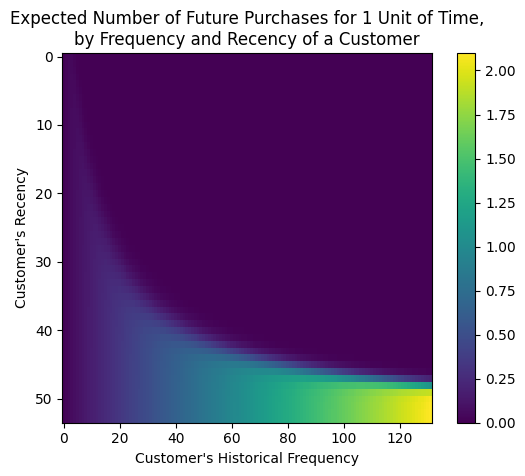

In [62]:
plot_frequency_recency_matrix(bgf)

<Axes: title={'center': 'Probability Customer is Alive,\nby Frequency and Recency of a Customer'}, xlabel="Customer's Historical Frequency", ylabel="Customer's Recency">

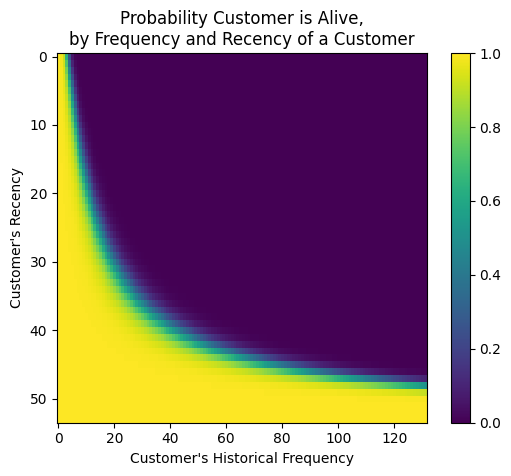

In [63]:
plot_probability_alive_matrix(bgf)

<Axes: title={'center': 'Frequency of Repeat Transactions'}, xlabel='Number of Calibration Period Transactions', ylabel='Customers'>

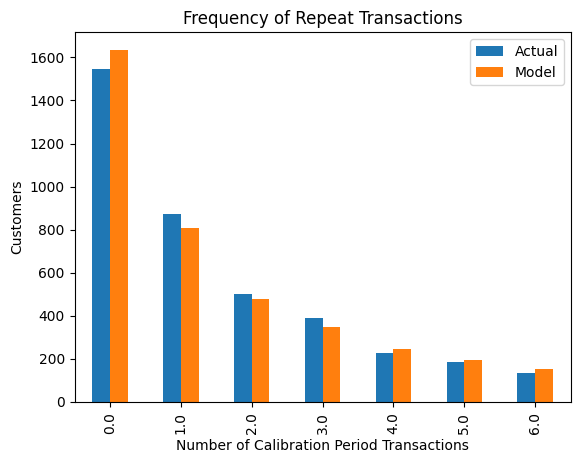

In [64]:
plot_period_transactions(bgf)

#### Train Test Split

In [65]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [66]:
# Define cutoff dates (weekly basis)
end_date = df['InvoiceDate'].max()
calibration_end = end_date - pd.Timedelta(weeks=12)

summary_cal_holdout = calibration_and_holdout_data(
    transactions = df,
    customer_id_col = 'CustomerID',
    datetime_col = 'InvoiceDate',
    monetary_value_col = 'TotalPrice',
    freq = 'W',  # Weekly aggregation
    calibration_period_end = calibration_end,
    observation_period_end = end_date
)

summary_cal_holdout.head()



,frequency_cal,recency_cal,T_cal,monetary_value_cal,frequency_holdout,monetary_value_holdout,duration_holdout
CustomerID,,,,,,,
12346.0,0.0,0.0,34.0,0.0000,0.0,0.000000,12.0
12347.0,4.0,34.0,40.0,519.7675,2.0,26.192069,12.0
12348.0,2.0,16.0,39.0,297.2200,1.0,103.333333,12.0
12350.0,0.0,0.0,32.0,0.0000,0.0,0.000000,12.0
12352.0,3.0,5.0,30.0,421.7700,3.0,20.090000,12.0


In [67]:
# 1. Drop customers with no repeat purchases in calibration
summary_cal_holdout = summary_cal_holdout[summary_cal_holdout['frequency_cal'] > 0]

# 2. Drop customers with non-positive monetary value
summary_cal_holdout = summary_cal_holdout[summary_cal_holdout['monetary_value_cal'] > 0]

# 3. (Optional) Cap extreme outliers in monetary value
summary_cal_holdout['monetary_value_cal'] = summary_cal_holdout['monetary_value_cal'].clip(
    upper=summary_cal_holdout['monetary_value_cal'].quantile(0.95)
)

# 4. Reset index
summary_cal_holdout = summary_cal_holdout.reset_index()

# 5. Check correlation assumption for Gamma-Gamma
from scipy.stats import pearsonr
corr, pval = pearsonr(summary_cal_holdout['frequency_cal'], summary_cal_holdout['monetary_value_cal'])
print(f"Correlation: {corr:.3f}, p-value: {pval:.3f}")


Correlation: 0.192, p-value: 0.000


#### Model Fitting

In [68]:
from lifetimes import BetaGeoFitter

# Initialize the model
bgf = BetaGeoFitter(penalizer_coef=1e-06)

# Fit the model on calibration data
bgf.fit(
    frequency=summary_cal_holdout['frequency_cal'],
    recency=summary_cal_holdout['recency_cal'],
    T=summary_cal_holdout['T_cal']
)

print(bgf.summary)


            coef  se(coef)  lower 95% bound  upper 95% bound
r       2.826723  0.151461         2.529860         3.123587
alpha  22.793688  1.267057        20.310257        25.277120
a       0.009703  0.008002        -0.005981         0.025387
b       0.091784  0.075805        -0.056794         0.240362


#### Model Evaluation

In [69]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Predict expected purchases in holdout period
summary_cal_holdout['predicted_purchases_holdout'] = bgf.predict(
    summary_cal_holdout['duration_holdout'],
    summary_cal_holdout['frequency_cal'],
    summary_cal_holdout['recency_cal'],
    summary_cal_holdout['T_cal']
)

# Evaluate
y_true = summary_cal_holdout['frequency_holdout']
y_pred = summary_cal_holdout['predicted_purchases_holdout']

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)

print(f"RMSE: {rmse:.3f}, MAE: {mae:.3f}")


RMSE: 1.420, MAE: 1.026


<Axes: title={'center': 'Expected Number of Future Purchases for 1 Unit of Time,\nby Frequency and Recency of a Customer'}, xlabel="Customer's Historical Frequency", ylabel="Customer's Recency">

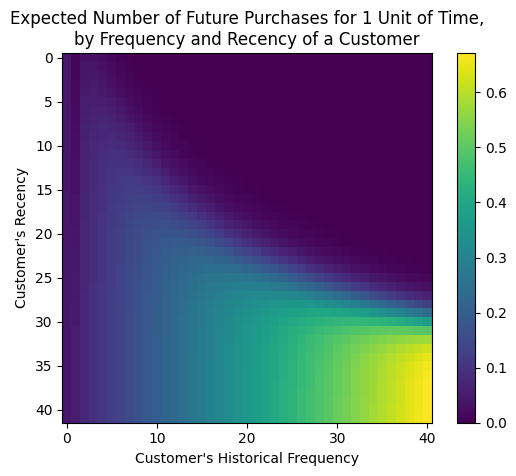

In [70]:
plot_frequency_recency_matrix(bgf)

<Axes: title={'center': 'Actual Purchases in Holdout Period vs Predicted Purchases'}, xlabel='Purchases in calibration period', ylabel='Average of Purchases in Holdout Period'>

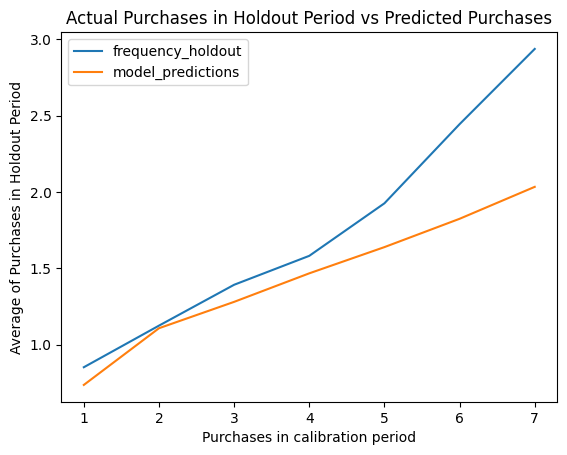

In [71]:
from lifetimes.plotting import plot_calibration_purchases_vs_holdout_purchases

plot_calibration_purchases_vs_holdout_purchases(bgf, summary_cal_holdout)


Validation using usual Machine Learning metrics. Note that the following metrics below were computed on customers with at least one repeat purchase in calibration, since BG/NBD requires frequency > 0 for stable predictions.

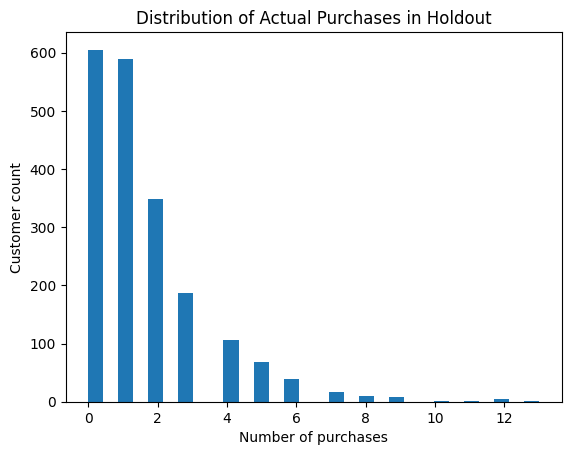

In [72]:
plt.hist(summary_cal_holdout['frequency_holdout'], bins=30)
plt.title("Distribution of Actual Purchases in Holdout")
plt.xlabel("Number of purchases")
plt.ylabel("Customer count")
plt.show()


#### Predict Future Purchases given time T

In [73]:
def predict_future_purchases(bgf, summary_data, horizons=[4, 8, 12, 24]):
    results = summary_data[['CustomerID']].copy()
    for t in horizons:
        results[f'pred_{t}_weeks'] = bgf.predict(
            t,
            summary_data['frequency_cal'],
            summary_data['recency_cal'],
            summary_data['T_cal']
        )
    return results

pred_table = predict_future_purchases(bgf, summary_cal_holdout)
pred_table.head()


,CustomerID,pred_4_weeks,pred_8_weeks,pred_12_weeks,pred_24_weeks
0,12347.0,0.431929,0.863398,1.294452,2.585445
1,12348.0,0.287971,0.575503,0.862647,1.722136
2,12352.0,0.369161,0.737800,1.105979,2.208194
3,12356.0,0.151988,0.303596,0.454883,0.907224
4,12359.0,0.321581,0.642643,0.963249,1.922803


#### Probability of a Customer being Alive

**Interpretation:** Higher probability_alive means the model believes the customer is still active. Typically, customers with recent purchases and higher frequency have higher probabilities.

In [74]:
summary_cal_holdout['probability_alive'] = bgf.conditional_probability_alive(
    summary_cal_holdout['frequency_cal'],
    summary_cal_holdout['recency_cal'],
    summary_cal_holdout['T_cal']
)

In [75]:
# Inspect top customers most likely to be alive
summary_cal_holdout[['CustomerID', 'frequency_cal', 'recency_cal', 'T_cal', 'probability_alive']] \
    .sort_values('probability_alive', ascending=False) \
    .head(10)


,CustomerID,frequency_cal,recency_cal,T_cal,probability_alive
765,14606.0,40.0,41.0,41.0,0.999752
1845,17841.0,39.0,41.0,41.0,0.999745
743,14527.0,37.0,41.0,41.0,0.999731
1007,15311.0,36.0,41.0,41.0,0.999724
219,12971.0,35.0,41.0,41.0,0.999715
874,14911.0,35.0,41.0,41.0,0.999715
151,12748.0,34.0,41.0,41.0,0.999707
1357,16422.0,32.0,41.0,41.0,0.999688
485,13798.0,29.0,41.0,41.0,0.999655
1660,17315.0,24.0,39.0,39.0,0.999580


In [76]:
# Inspect customers unlikely to be alive
summary_cal_holdout[['CustomerID', 'frequency_cal', 'recency_cal', 'T_cal', 'probability_alive']] \
    .sort_values('probability_alive', ascending=True) \
    .head(10)

,CustomerID,frequency_cal,recency_cal,T_cal,probability_alive
1624,17198.0,1.0,1.0,41.0,0.178425
1010,15332.0,1.0,1.0,41.0,0.178425
976,15224.0,1.0,1.0,40.0,0.187461
1381,16499.0,1.0,1.0,40.0,0.187461
1791,17691.0,1.0,1.0,40.0,0.187461
809,14723.0,1.0,2.0,41.0,0.202698
218,12967.0,1.0,2.0,41.0,0.202698
1885,17951.0,1.0,2.0,41.0,0.202698
174,12829.0,1.0,3.0,39.0,0.250432
75,12559.0,1.0,1.0,33.0,0.266139


This heatmap shows probability_alive across combinations of frequency and recency (in your chosen time units). It’s a great diagnostic to see how the model behaves.

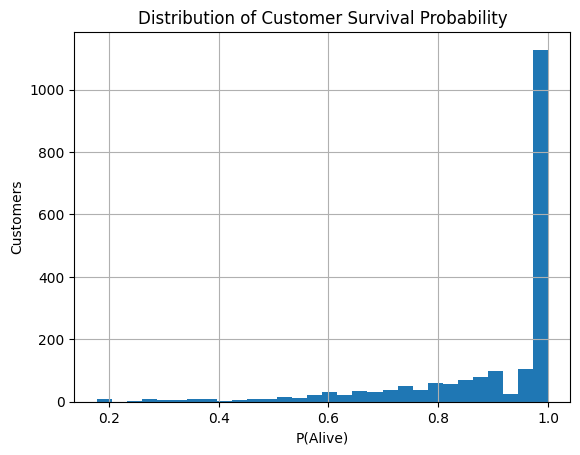

In [77]:
# Histogram of probabilities
summary_cal_holdout['probability_alive'].hist(bins=30)
plt.title("Distribution of Customer Survival Probability")
plt.xlabel("P(Alive)")
plt.ylabel("Customers")
plt.show()


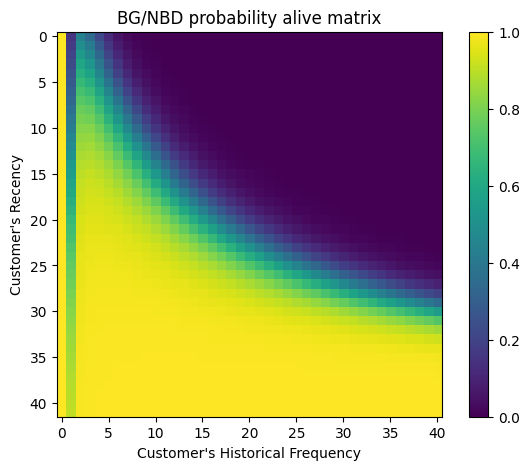

In [78]:
from lifetimes.plotting import plot_probability_alive_matrix

plt.figure(figsize=(7,5))
plot_probability_alive_matrix(bgf)
plt.title('BG/NBD probability alive matrix')
plt.show()


Probability of being alive for a Specific Customer

In [79]:
def plot_probability_alive_for_customer(bgf, summary_data, customer_id, horizon=12, step=1):
    """
    Plot probability alive over time for a given customer_id.

    Parameters
    ----------
    bgf : lifetimes.BetaGeoFitter
        A fitted BG/NBD model.
    summary_data : pd.DataFrame
        Calibration/holdout summary with columns ['CustomerID','frequency_cal','recency_cal','T_cal'].
    customer_id : int or str
        The customer ID to plot.
    horizon : int
        How far into the future to project (in same units as calibration, e.g. weeks).
    step : int
        Step size for the time grid.
    """
    # Ensure CustomerID is a column
    if 'CustomerID' not in summary_data.columns:
        summary_data = summary_data.reset_index()

    # Get this customer's calibration values
    row = summary_data.loc[summary_data['CustomerID'] == customer_id].iloc[0]

    # Build time grid
    times = np.arange(row['T_cal'], row['T_cal'] + horizon + step, step)

    # Compute probability alive
    probs = bgf.conditional_probability_alive(
        row['frequency_cal'],
        row['recency_cal'],
        times
    )

    # Plot
    plt.figure(figsize=(7,4))
    plt.plot(times, probs, marker='o')
    plt.xlabel('Time (same units as calibration)')
    plt.ylabel('Probability Alive')
    plt.title(f"Customer {customer_id} - Probability Alive Over Time")
    plt.grid(True, alpha=0.3)
    plt.show()


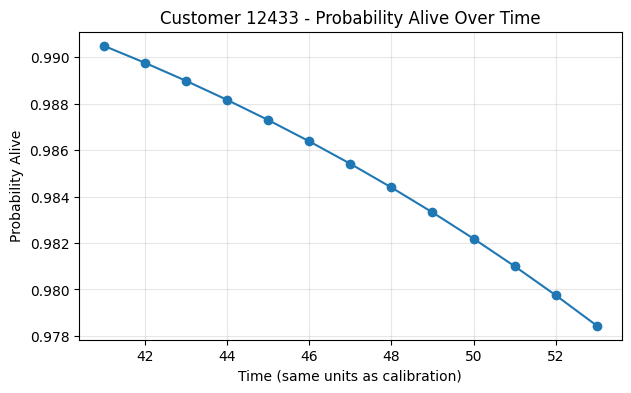

In [80]:
# Example: plot for customer 12433
plot_probability_alive_for_customer(bgf, summary_cal_holdout, customer_id=12433, horizon=12, step=1)


In [81]:
def plot_top_bottom_probability_alive(bgf, summary_data, top_n=5, horizon=12, step=1):
    """
    Plot probability alive curves for the top and bottom N customers
    ranked by probability_alive.
    """
    # Ensure CustomerID is a column
    if 'CustomerID' not in summary_data.columns:
        summary_data = summary_data.reset_index()

    # Sort customers by probability_alive
    top_customers = summary_data.sort_values('probability_alive', ascending=False).head(top_n)
    bottom_customers = summary_data.sort_values('probability_alive', ascending=True).head(top_n)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    # Plot top customers
    for _, row in top_customers.iterrows():
        times = np.arange(row['T_cal'], row['T_cal'] + horizon + step, step)
        probs = bgf.conditional_probability_alive(
            row['frequency_cal'], row['recency_cal'], times
        )
        axes[0].plot(times, probs, label=f"Cust {int(row['CustomerID'])}")
    axes[0].set_title(f"Top {top_n} Customers (Highest probability_alive)")
    axes[0].set_xlabel("Time (same units as calibration)")
    axes[0].set_ylabel("Probability Alive")
    axes[0].legend()

    # Plot bottom customers
    for _, row in bottom_customers.iterrows():
        times = np.arange(row['T_cal'], row['T_cal'] + horizon + step, step)
        probs = bgf.conditional_probability_alive(
            row['frequency_cal'], row['recency_cal'], times
        )
        axes[1].plot(times, probs, label=f"Cust {int(row['CustomerID'])}")
    axes[1].set_title(f"Bottom {top_n} Customers (Lowest probability_alive)")
    axes[1].set_xlabel("Time (same units as calibration)")
    axes[1].legend()

    plt.suptitle("BG/NBD Probability Alive Curves", fontsize=14)
    plt.tight_layout()
    plt.show()


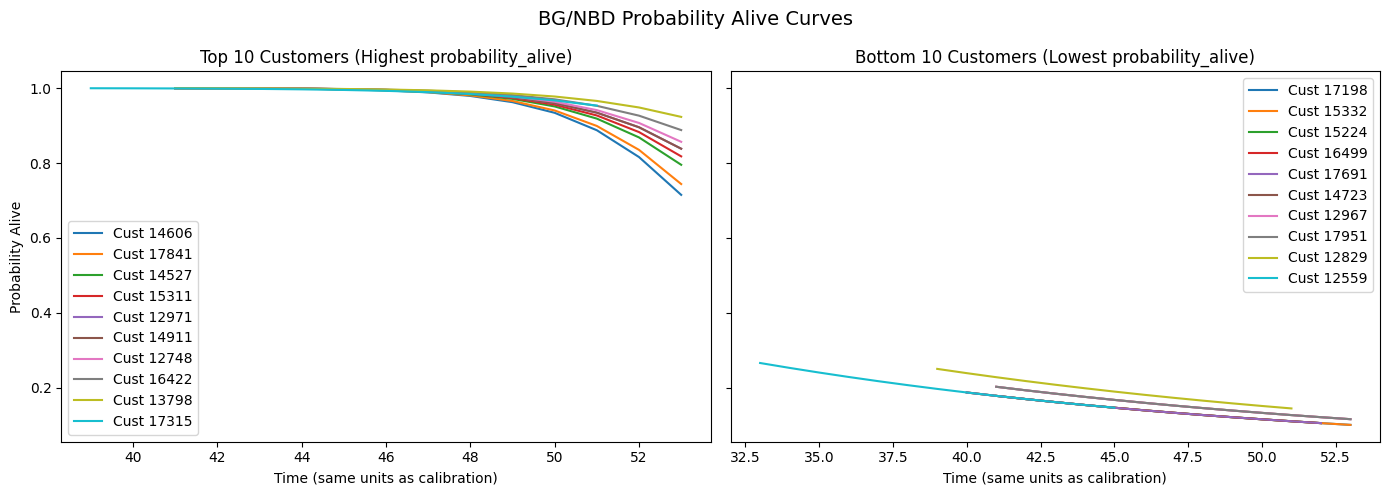

In [82]:
plot_top_bottom_probability_alive(bgf, summary_cal_holdout, top_n=10, horizon=12, step=1)


### Customer Lifetime Value

#### Gamma-Gamma Model

##### Model Fitting

In [83]:
from scipy.stats import pearsonr

# Filter calibration data
gg_data = summary_cal_holdout[
    (summary_cal_holdout['frequency_cal'] > 0) &
    (summary_cal_holdout['monetary_value_cal'] > 0)
]

# Compute Pearson correlation
corr, pval = pearsonr(summary_cal_holdout['frequency_cal'], summary_cal_holdout['monetary_value_cal'])

print(f"Pearson correlation: {corr:.3f}, p-value: {pval:.3f}")


Pearson correlation: 0.192, p-value: 0.000


In [84]:
from lifetimes import GammaGammaFitter

ggf = GammaGammaFitter(penalizer_coef=1e-6)
ggf.fit(
    gg_data['frequency_cal'],
    gg_data['monetary_value_cal']
)


<lifetimes.GammaGammaFitter: fitted with 1987 subjects, p: 4.52, q: 2.77, v: 160.73>

**ggf.summary**

- The model suggests that customers spend, on average, ~365 per transaction, with moderate variation across the population.
- The p and q values around 2–3 suggest moderate variation — customers differ in spend, but not wildly.
- Because the correlation assumption check (Pearson’s r) was close to zero, it’s valid to combine this Gamma-Gamma model with your BG/NBD purchase frequency model.
- Together, we can estimate Customer Lifetime Value (CLV) by the following:

```
CLV:
Expected Transactions (BG/NBD) × Expected Spend per Transaction (Gamma-Gamma)
```

In [85]:
ggf.summary

,coef,se(coef),lower 95% bound,upper 95% bound
p,4.519290,0.223401,4.081425,4.957156
q,2.771981,0.097366,2.581145,2.962818
v,160.731371,10.023689,141.084941,180.377802


In [86]:
gg_data['expected_avg_value'] = ggf.conditional_expected_average_profit(
    gg_data['frequency_cal'],
    gg_data['monetary_value_cal']
)


In [87]:
weeks = 12  # horizon
discount_rate = 0.00  # weekly discount rate

gg_data['predicted_clv'] = ggf.customer_lifetime_value(
    bgf,
    gg_data['frequency_cal'],
    gg_data['recency_cal'],
    gg_data['T_cal'],
    gg_data['monetary_value_cal'],
    time=weeks,             # number of weeks into future
    discount_rate=discount_rate,  # weekly discount rate
    freq='W'
)

##### Model Evaluation

In [88]:
# Actual holdout spending
y_true_value = gg_data['monetary_value_holdout']

# Predicted spending (approximation: avg value * predicted purchases)
y_pred_value = gg_data['expected_avg_value'] * gg_data['predicted_purchases_holdout']

# Drop NaNs if any
mask = (~y_true_value.isna()) & (~y_pred_value.isna())
y_true_value = y_true_value[mask]
y_pred_value = y_pred_value[mask]

# Evaluation metrics
mae_value = mean_absolute_error(y_true_value, y_pred_value)
rmse_value = np.sqrt(mean_squared_error(y_true_value, y_pred_value))
r2_value = r2_score(y_true_value, y_pred_value)

print(f"Gamma–Gamma Evaluation on Holdout:")
print(f"  MAE : {mae_value:.2f}")
print(f"  RMSE: {rmse_value:.2f}")
print(f"  R²  : {r2_value:.3f}")


Gamma–Gamma Evaluation on Holdout:
  MAE : 516.44
  RMSE: 796.08
  R²  : -97.837


#### Hybrid CLV: (BG/NBD + ML)

##### Feature Selection

In [89]:
# --- Start with calibration data ---
X = summary_cal_holdout.copy()  # calibration data
y = summary_cal_holdout['monetary_value_holdout']  # target

# --- Monetary features ---
X['avg_monetary_value'] = X['monetary_value_cal']
X['total_cal_value'] = X['monetary_value_cal'] * (X['frequency_cal'] + 1)
X['monetary_per_week'] = X['total_cal_value'] / X['T_cal'].replace(0, np.nan)

# --- Ratios and derived metrics ---
X['recency_ratio'] = X['recency_cal'] / X['T_cal'].replace(0, np.nan)
X['value_per_purchase'] = X['monetary_value_cal'] / (X['frequency_cal'] + 1)

# --- BG/NBD probabilistic outputs ---
X['predicted_purchases'] = bgf.predict(
    t=12,  # choose your horizon
    frequency=X['frequency_cal'],
    recency=X['recency_cal'],
    T=X['T_cal']
)
X['prob_alive'] = bgf.conditional_probability_alive(
    X['frequency_cal'],
    X['recency_cal'],
    X['T_cal']
)

# --- Optional: future/past ratio if holdout exists ---
if 'monetary_value_holdout' in summary_cal_holdout.columns:
    X['future_past_ratio'] = y / (X['monetary_value_cal'] + 1)

# --- Final features for XGBoost ---
feature_cols = [
    'frequency_cal', 'recency_cal', 'T_cal',
    'avg_monetary_value', 'total_cal_value', 'monetary_per_week',
    'recency_ratio', 'value_per_purchase',
    'predicted_purchases', 'prob_alive'
]

X = X[feature_cols]

##### Model Fitting and Hyperparameter Tuning

In [90]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [91]:
# --- Hyperparameter grid ---
params = {
    'n_estimators': [300, 500],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.03, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'reg_lambda': [5.0, 10.0]
}

# --- Base model ---
xgb = XGBRegressor(
    random_state=42,
    objective='reg:squarederror',
    n_jobs=-1
)

# --- Grid search using RMSE (negative because sklearn maximizes scores) ---
grid = GridSearchCV(
    xgb,
    param_grid=params,
    cv=3,
    scoring='neg_root_mean_squared_error',  # use RMSE as main metric
    n_jobs=-1,
    verbose=1
)

# --- Fit the model ---
grid.fit(X_train, y_train)

# --- Best model ---
best_xgb = grid.best_estimator_

print("✅ Best Parameters:")
print(grid.best_params_)

# --- Evaluate on test data ---
y_pred = best_xgb.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = grid.score(X_test, y_test)  # note: this will be negative RMSE because of scoring

print("\n📊 Model Performance on Test Set:")
print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {best_xgb.score(X_test, y_test):.4f}")

Fitting 3 folds for each of 144 candidates, totalling 432 fits
✅ Best Parameters:
{'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 300, 'reg_lambda': 10.0, 'subsample': 1.0}

📊 Model Performance on Test Set:
MAE : 20.12
RMSE: 39.92
R²  : -0.5191


##### Model Evaluation

In [92]:
y_pred = best_xgb.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("XGBoost Hybrid Evaluation on Holdout:")
print(f"  MAE : {mae:.3f}")
print(f"  RMSE: {rmse:.3f}")
print(f"  R²  : {r2:.3f}")

XGBoost Hybrid Evaluation on Holdout:
  MAE : 20.119
  RMSE: 39.919
  R²  : -0.519


##### Feature Importance

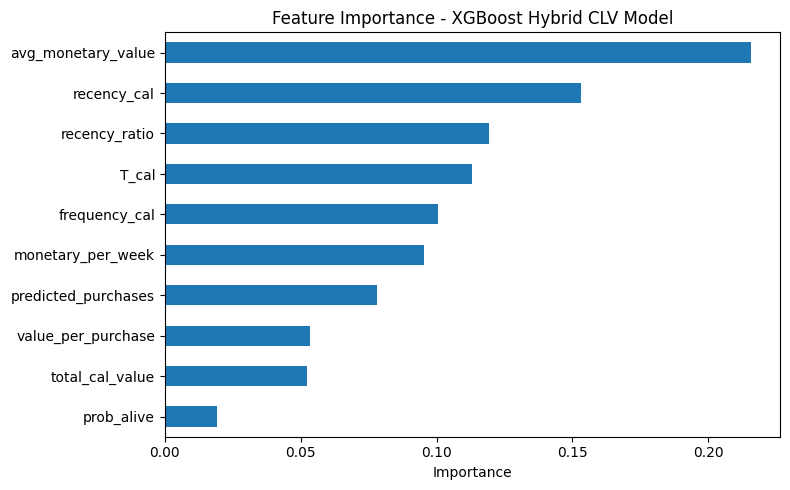

In [93]:
importance = pd.Series(best_xgb.feature_importances_, index=X.columns).sort_values(ascending=True)
plt.figure(figsize=(8,5))
importance.plot(kind='barh')
plt.title("Feature Importance - XGBoost Hybrid CLV Model")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

### Customer Segmentation

##### Customer Segmentation Insights & Marketing Strategy Recommendations

Based on behavioral and predictive features derived from our models—including BG/NBD for purchase frequency and probability alive, and XGBoost hybrid predictions for total CLV—we performed feature engineering, outlier treatment, and transformations before applying K-Means clustering. PCA was used to visualize cluster separation and patterns.

We identified three distinct customer segments with unique purchasing behaviors. Understanding these segments enables targeted marketing strategies, optimized customer engagement, and maximized revenue potential.

---

**Customer Segment Summary**

| Cluster | Frequency (avg) | Recency (weeks) | Tenure (weeks) | Predicted CLV (£) | Segment Insight                                                                                                                                               |
| ------- | --------------- | --------------- | -------------- | ----------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| 0       | 5.11            | 30.42           | 34.65          | 22.83             | **Mid-Value Customers**: Moderate frequency and tenure, contributing meaningful revenue. Loyal and consistent buyers with potential for upselling and growth. |
| 1       | 1.37            | 12.11           | 25.39          | 13.17             | **Occasional Buyers**: Low frequency, shorter tenure, smaller revenue contribution. At risk of churn; best targeted with reactivation campaigns.              |
| 2       | 9.43            | 33.28           | 36.75          | 219.02            | **VIP High-Value Customers**: Very high frequency, extremely high CLV, and large transaction values. Loyal, top-tier customers requiring retention focus.     |


---
**Behavioural Highlight by Cluster**
| Cluster                          | Description                           | Behavioral Highlights                                                                                                                                                                                                                |
| -------------------------------- | ------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| **0 — Mid-Value Customers**      | Frequent, loyal, moderate-value group | • Purchases: ~5.1 avg<br>• Recent: recency ≈ 30 weeks, tenure ≈ 35 weeks<br>• Alive probability: 0.98<br>• CLV (XGB) ≈ 22.8<br>• Value per purchase ≈ 4.77<br>• Stable segment; ideal for upselling and personalized campaigns       |
| **1 — Occasional Buyers**        | Low-frequency, low-engagement group   | • Purchases: ~1.37<br>• Shorter tenure: 25 weeks<br>• Alive probability: 0.78<br>• CLV ≈ 13.17<br>• Recency ratio ≈ 0.51 → haven’t purchased recently<br>• Target with reactivation and win-back strategies                          |
| **2 — VIP High-Value Customers** | High-value, high-spend loyalists      | • Purchases: ~9.43<br>• Long tenure: ~37 weeks<br>• Alive probability: 0.97<br>• CLV ≈ 219<br>• Value per purchase ≈ 38.14 → large order sizes<br>• Loyal, premium segment; prioritize retention, exclusivity, and advocacy programs |


---

**Marketing Strategy per Segment:**

Cluster 0 — Mid-Value Customers:
- Moderate engagement and revenue contribution.
- Focus on upselling, cross-selling, bundle offers, and personalized promotions.
- Goal: increase purchase frequency and average order value to move customers toward VIP tier.

Cluster 1 — Occasional Buyers:
- Low frequency, short tenure, and low predicted CLV.
- Focus on reactivation campaigns, win-back offers, limited-time incentives, and targeted product recommendations.
- Goal: increase engagement and reduce churn risk.

Cluster 2 — VIP High-Value Customers:
- High frequency, high predicted CLV, and consistent purchase behavior.
- Focus on retention programs, VIP exclusives, early access to new products, loyalty rewards, and advocacy initiatives.
- Goal: maintain loyalty, maximize lifetime value, and strengthen brand advocacy.

---

**Strategic Summary**

- Segmentation enables precise targeting: Allocate marketing resources efficiently based on customer behavior.

- Revenue growth potential: Cluster 0 has potential for upselling, while Cluster 1 can be activated with win-back campaigns.

- Retention focus: Cluster 2 VIPs must be nurtured to prevent revenue loss.

- Data-driven approach: Using features from BG/NBD and XGBoost ensures clusters reflect both historical and predicted behavior.

- Visualization: PCA confirms clear separation of clusters, aiding interpretation and reporting.

**Overall:** Aligning marketing campaigns with these segments maximizes engagement, revenue, and customer lifetime value while delivering a personalized experience that strengthens loyalty and advocacy.

#### Feature Selection

| **Feature**               | **Description**                                                            | **Source**              |
| ------------------------- | -------------------------------------------------------------------------- | ----------------------- |
| **frequency**             | Number of repeat purchases during the calibration period                   | BG/NBD input            |
| **recency**               | Weeks since the customer’s last purchase during the calibration period     | BG/NBD input            |
| **tenure**                | Customer’s age in weeks during the observation period                      | BG/NBD input            |
| **monetary_value**        | Average monetary value of transactions during the calibration period       | Transactional data      |
| **prob_alive**            | Probability that the customer is still active                              | BG/NBD output           |
| **predicted_purchases**   | Expected number of future transactions (e.g., next 12 weeks)               | BG/NBD output |
| **predicted_clv_xgb**     | Predicted total customer lifetime value (future revenue forecast)          | XGBoost model output    |
| **log_predicted_clv_xgb** | Log-transformed predicted CLV (for normalization and clustering stability) | XGBoost model output    |
| **value_per_purchase**    | Estimated average value per transaction based on predicted CLV             | Derived metric          |
| **recency_ratio**         | Recency divided by tenure (recency relative to customer age)               | Derived metric          |



In [94]:
# --- Start with customer-level dataset ---
segm_df = summary_cal_holdout.copy()

segm_df = segm_df.merge(
    pred_table[['CustomerID', 'pred_12_weeks']],
    on='CustomerID',
    how='left'
)


# --- Behavioral features (calibration period) ---
segm_df['frequency'] = segm_df['frequency_cal']
segm_df['recency'] = segm_df['recency_cal']
segm_df['tenure'] = segm_df['T_cal']
segm_df['monetary_value'] = segm_df['monetary_value_cal']

# --- Probabilistic model features ---
segm_df['prob_alive'] = bgf.conditional_probability_alive(
    segm_df['frequency'], segm_df['recency'], segm_df['tenure']
)

# --- Predicted features from hybrid XGBoost ---
segm_df['predicted_purchases'] = segm_df['pred_12_weeks']
segm_df['predicted_clv_xgb'] = best_xgb.predict(X)  # aligned to the dataset
segm_df['predicted_clv_xgb'] = segm_df['predicted_clv_xgb'].clip(lower=0)
segm_df['log_predicted_clv_xgb'] = np.log1p(segm_df['predicted_clv_xgb'])

# --- Derived metrics ---
segm_df['value_per_purchase'] = segm_df['predicted_clv_xgb'] / (segm_df['frequency'] + 1)
segm_df['recency_ratio'] = segm_df['recency'] / segm_df['tenure']

# --- Features for clustering ---
segm_features = segm_df[['frequency', 'recency', 'tenure', 'monetary_value',
                         'prob_alive', 'predicted_purchases', 'predicted_clv_xgb',
                         'log_predicted_clv_xgb', 'value_per_purchase', 'recency_ratio']]


#### Outlier Handling, Transformation and Scaling

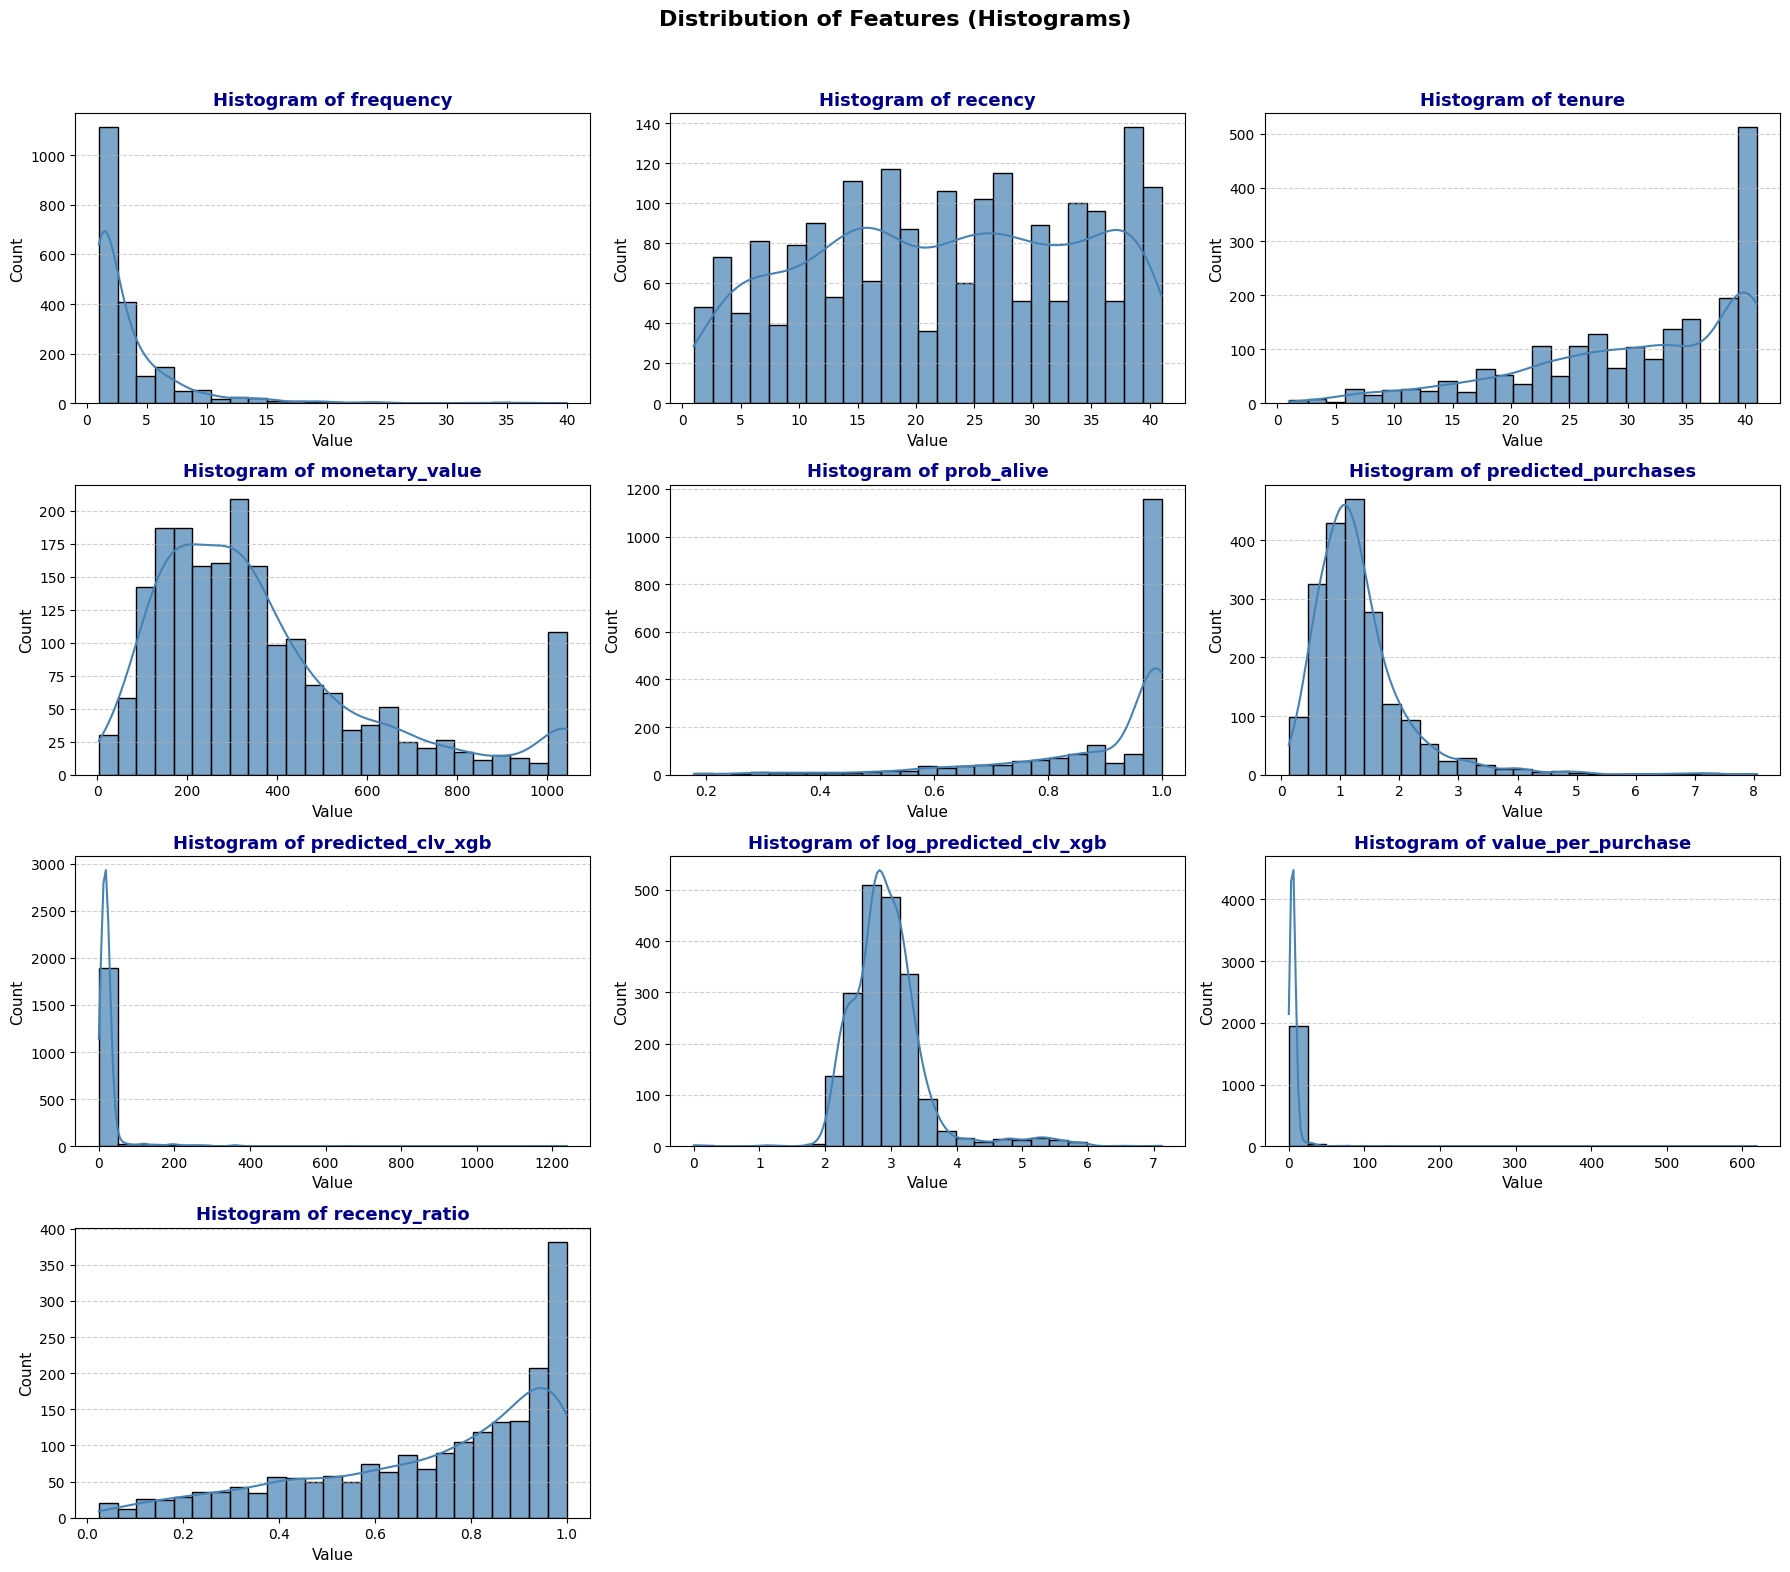

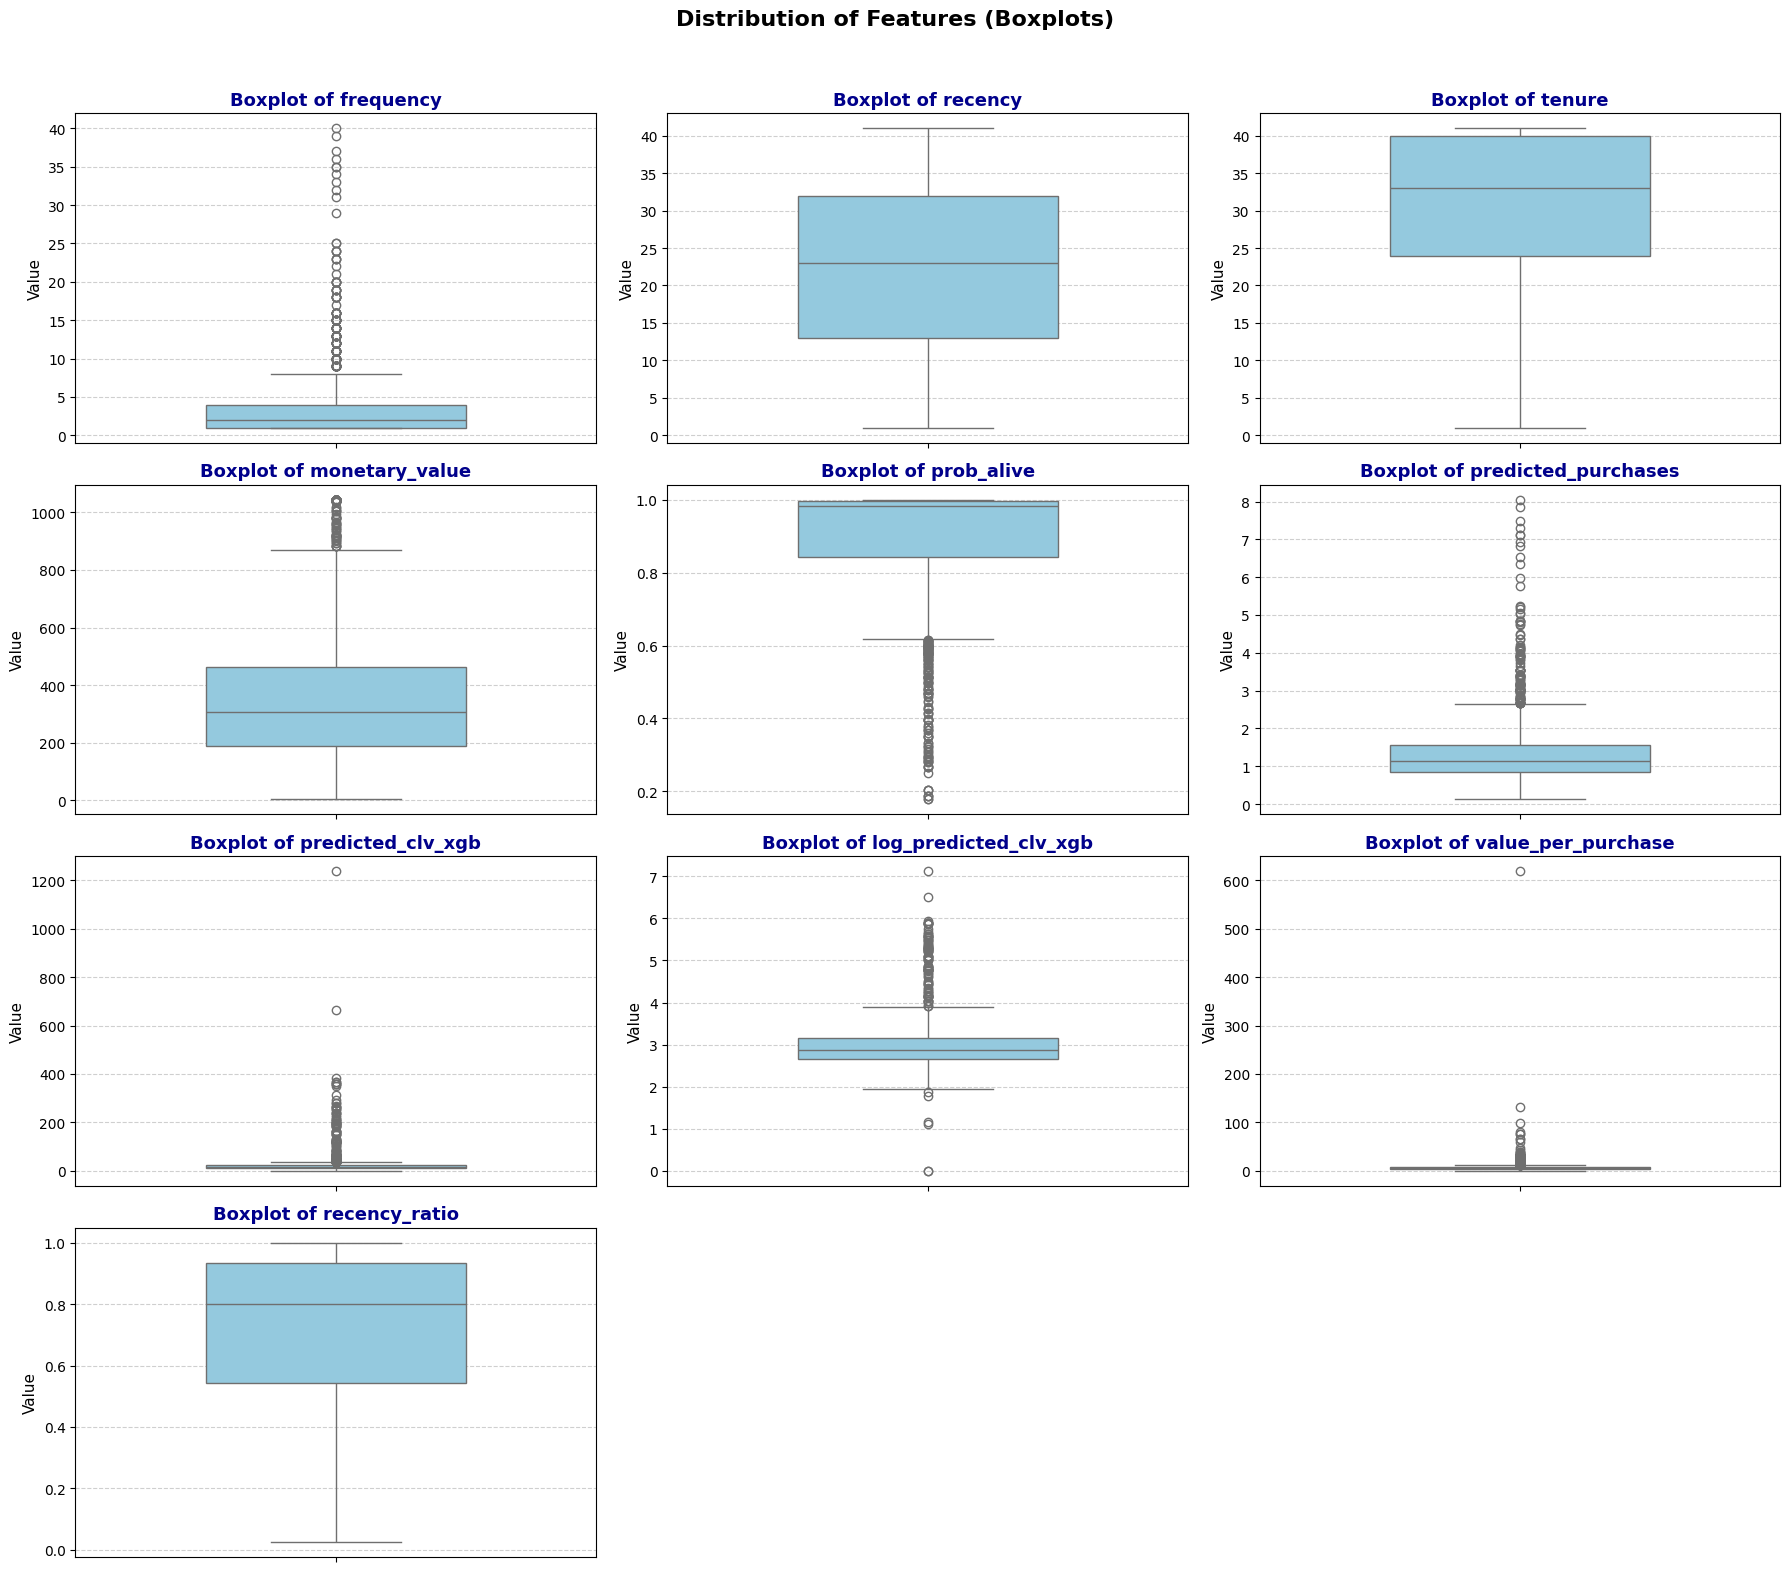

In [95]:
num_features = len(segm_features.columns)
cols_per_row = 3
rows_needed = int(np.ceil(num_features / cols_per_row))

# --- Histograms ---
fig, axes = plt.subplots(rows_needed, cols_per_row, figsize=(18, rows_needed * 4))
axes = axes.flatten()  # flatten to 1D array for easy indexing

for i, col in enumerate(segm_features.columns):
    sns.histplot(segm_features[col], bins=25, kde=True, ax=axes[i],
                 color='steelblue', alpha=0.7)
    axes[i].set_title(f"Histogram of {col}", fontsize=13, fontweight='bold', color='darkblue')
    axes[i].set_xlabel("Value", fontsize=11)
    axes[i].set_ylabel("Count", fontsize=11)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

# Hide any unused axes
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.suptitle("Distribution of Features (Histograms)", fontsize=16, fontweight='bold', color='black')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


# --- Boxplots ---
fig, axes = plt.subplots(rows_needed, cols_per_row, figsize=(18, rows_needed * 4))
axes = axes.flatten()

for i, col in enumerate(segm_features.columns):
    sns.boxplot(y=segm_features[col], ax=axes[i], color='skyblue', width=0.5)
    axes[i].set_title(f"Boxplot of {col}", fontsize=13, fontweight='bold', color='darkblue')
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Value", fontsize=11)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

# Hide unused axes
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.suptitle("Distribution of Features (Boxplots)", fontsize=16, fontweight='bold', color='black')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()



In [96]:
class OutlierCapper(BaseEstimator, TransformerMixin):
    """
    Caps outliers in numeric columns based on specified percentiles.

    Parameters
    ----------
    lower_pct : float, default=0.01
        Lower percentile threshold (e.g., 0.01 for 1st percentile).

    upper_pct : float, default=0.99
        Upper percentile threshold (e.g., 0.99 for 99th percentile).
    """
    def __init__(self, lower_pct=0.01, upper_pct=0.99):
        self.lower_pct = lower_pct
        self.upper_pct = upper_pct
        self.lower_bounds_ = None
        self.upper_bounds_ = None

    def fit(self, X, y=None):
        """
        Compute lower and upper bounds for numeric columns.
        """
        if not isinstance(X, pd.DataFrame):
            raise ValueError("X must be a pandas DataFrame.")

        numeric_cols = X.select_dtypes(include='number').columns
        self.lower_bounds_ = X[numeric_cols].quantile(self.lower_pct)
        self.upper_bounds_ = X[numeric_cols].quantile(self.upper_pct)
        return self

    def transform(self, X):
        """
        Cap the outliers in numeric columns.
        """
        if not isinstance(X, pd.DataFrame):
            raise ValueError("X must be a pandas DataFrame.")

        X_capped = X.copy()
        numeric_cols = X.select_dtypes(include='number').columns

        for col in numeric_cols:
            X_capped[col] = X_capped[col].clip(
                lower=self.lower_bounds_[col],
                upper=self.upper_bounds_[col]
            )
        return X_capped


In [97]:
# --- Initialize OutlierCapper ---
capper = OutlierCapper(lower_pct=0.01, upper_pct=0.99)

# --- Fit & transform on features for clustering ---
segm_features_capped = capper.fit_transform(segm_features)

# Optional: keep same column names
segm_features_capped = pd.DataFrame(segm_features_capped, columns=segm_features.columns, index=segm_features.index)

In [98]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(segm_features_capped)

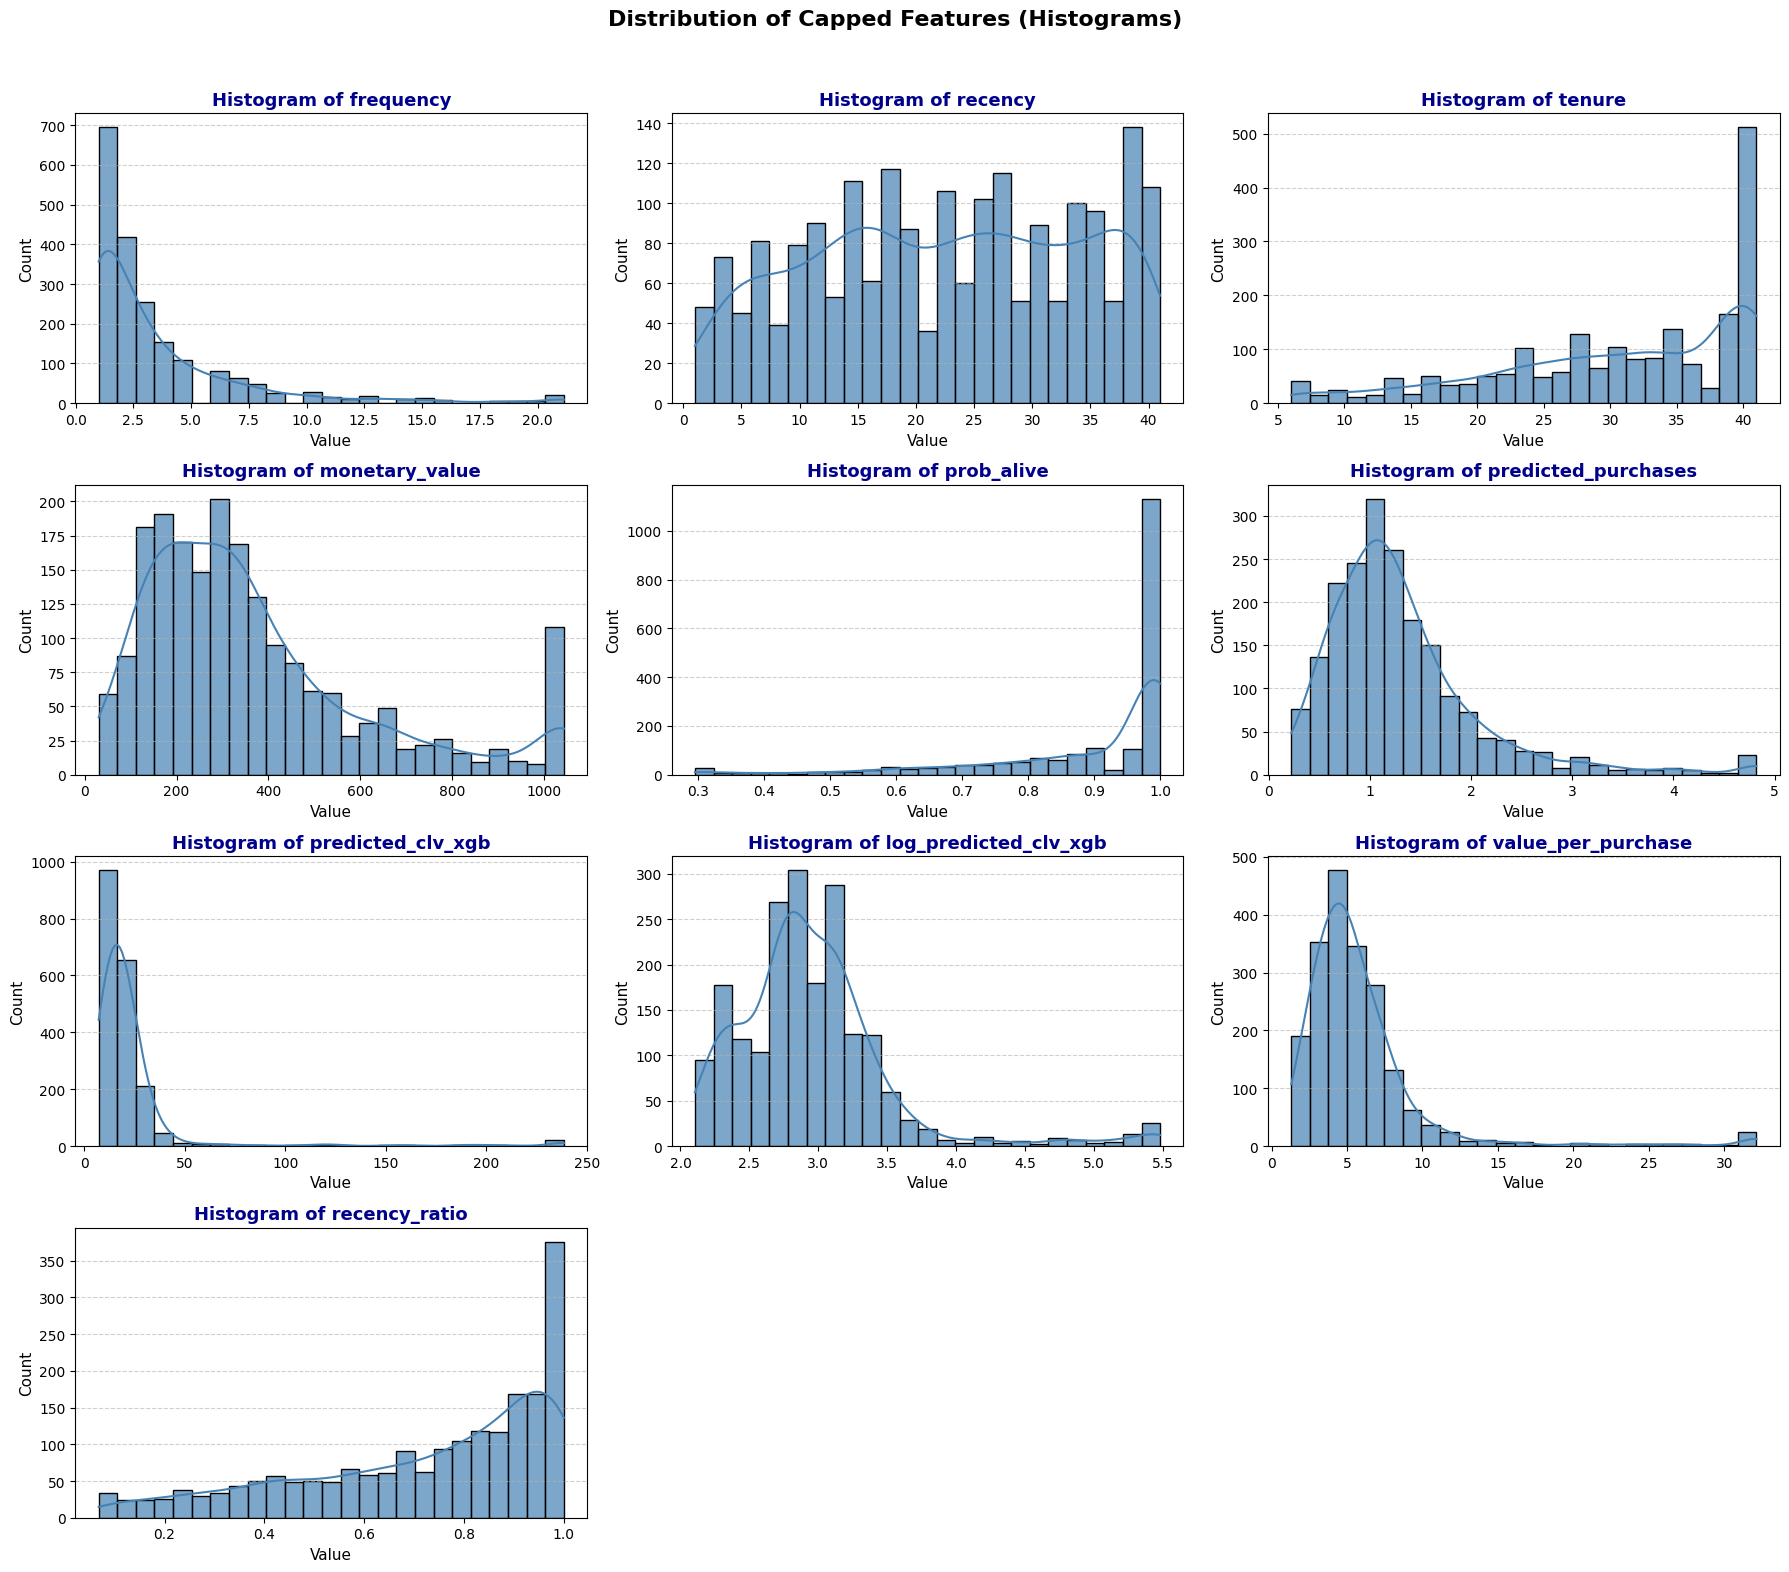

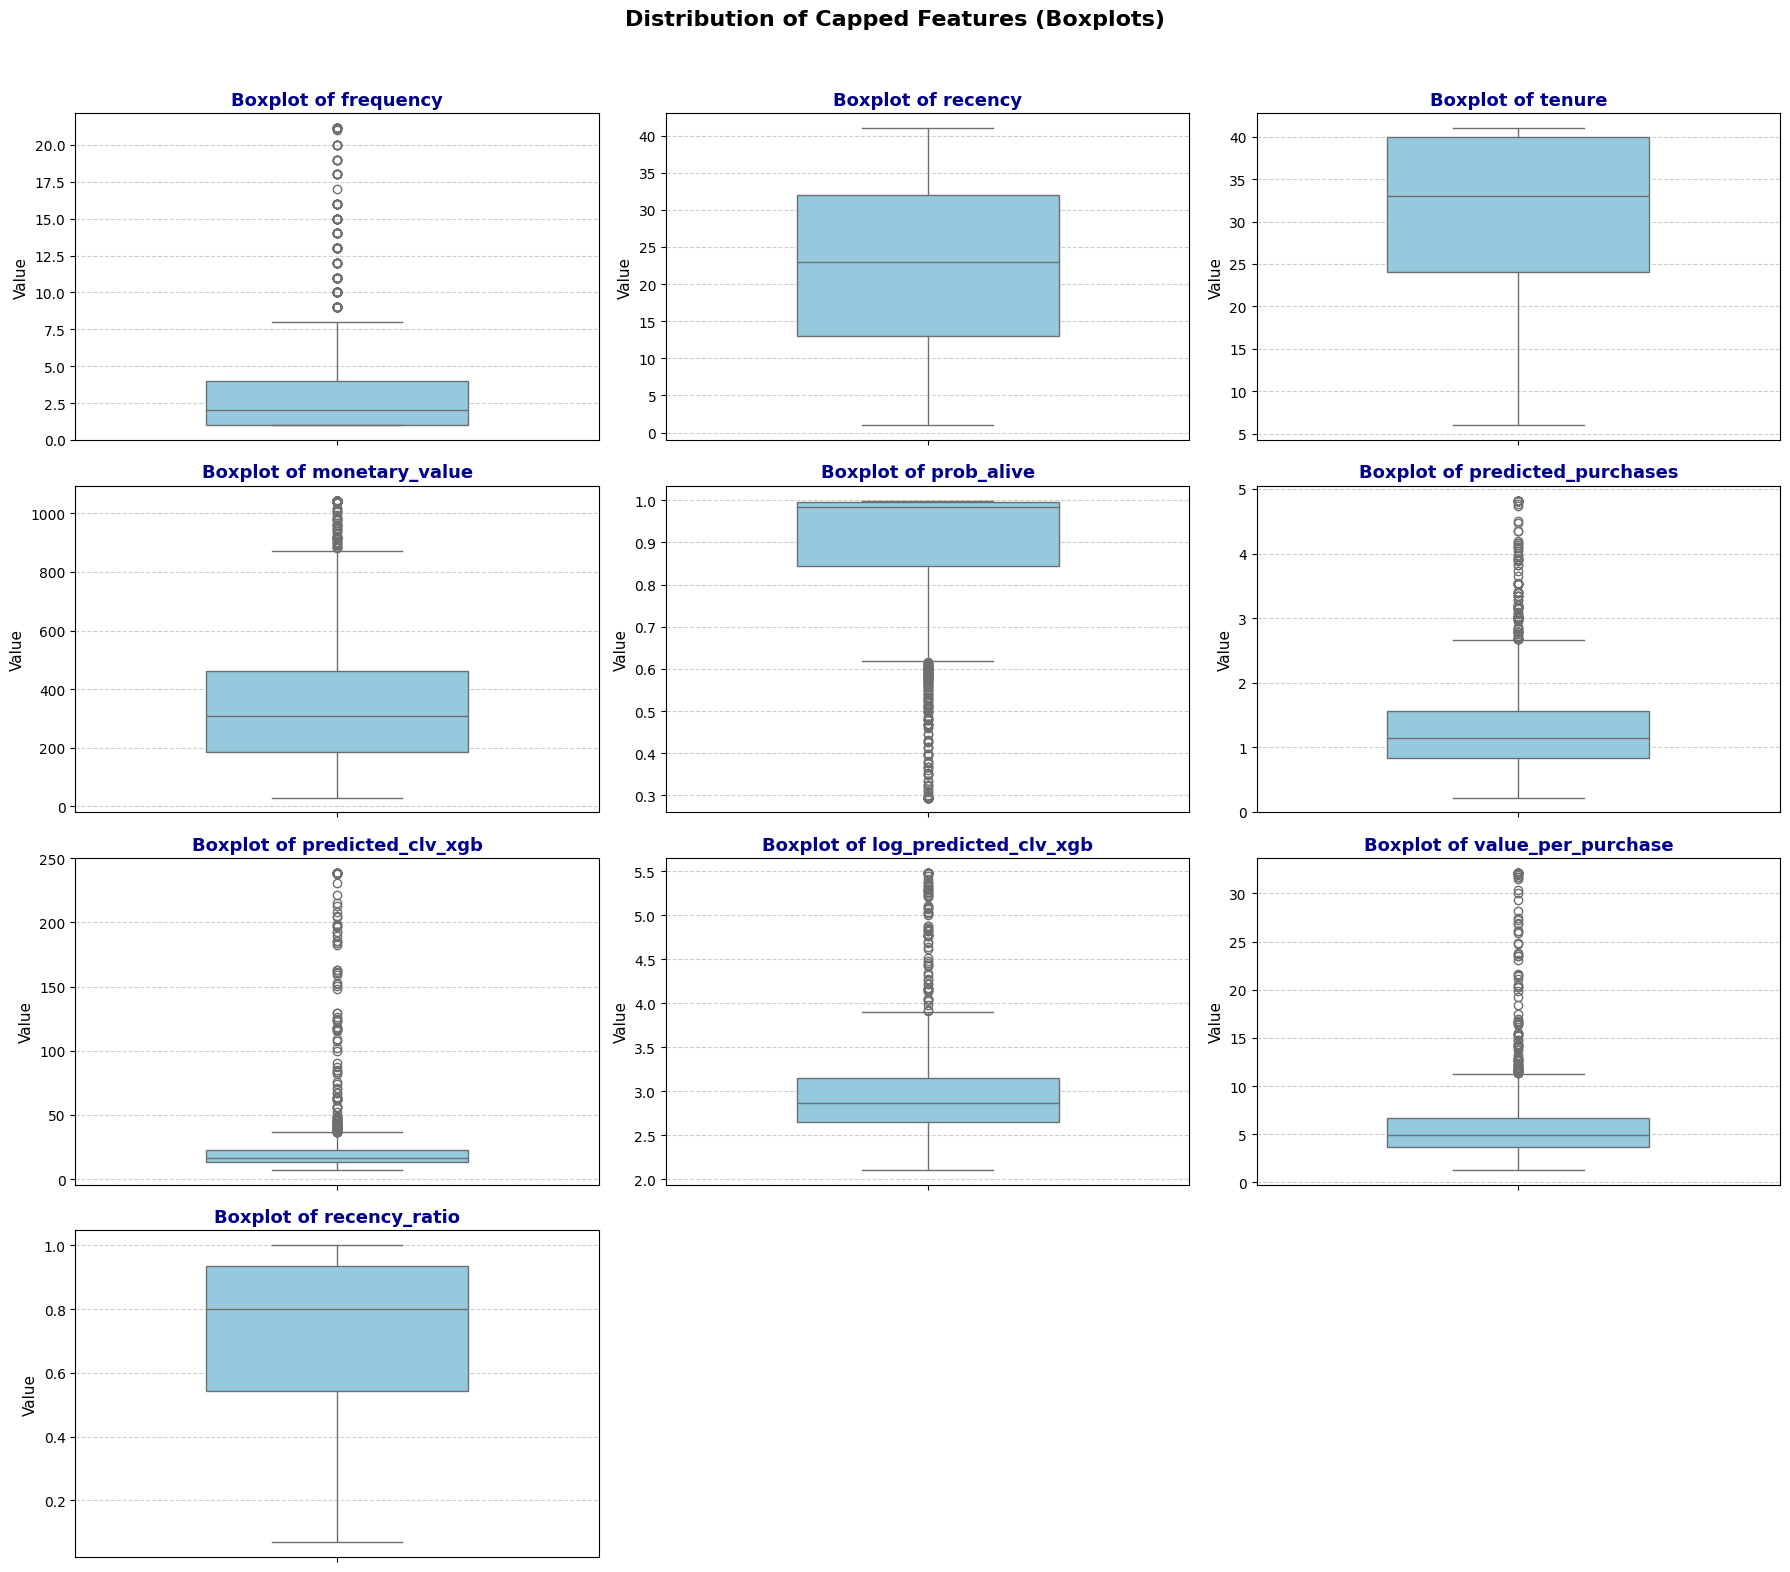

In [99]:
num_features = len(segm_features.columns)
cols_per_row = 3
rows_needed = int(np.ceil(num_features / cols_per_row))

# --- Histograms ---
fig, axes = plt.subplots(rows_needed, cols_per_row, figsize=(18, rows_needed * 4))
axes = axes.flatten()  # flatten to 1D array for easy indexing

for i, col in enumerate(segm_features.columns):
    sns.histplot(segm_features_capped[col], bins=25, kde=True, ax=axes[i],
                 color='steelblue', alpha=0.7)
    axes[i].set_title(f"Histogram of {col}", fontsize=13, fontweight='bold', color='darkblue')
    axes[i].set_xlabel("Value", fontsize=11)
    axes[i].set_ylabel("Count", fontsize=11)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

# Hide any unused axes
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.suptitle("Distribution of Capped Features (Histograms)", fontsize=16, fontweight='bold', color='black')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


# --- Boxplots ---
fig, axes = plt.subplots(rows_needed, cols_per_row, figsize=(18, rows_needed * 4))
axes = axes.flatten()

for i, col in enumerate(segm_features.columns):
    sns.boxplot(y=segm_features_capped[col], ax=axes[i], color='skyblue', width=0.5)
    axes[i].set_title(f"Boxplot of {col}", fontsize=13, fontweight='bold', color='darkblue')
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Value", fontsize=11)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

# Hide any unused axes
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.suptitle("Distribution of Capped Features (Boxplots)", fontsize=16, fontweight='bold', color='black')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


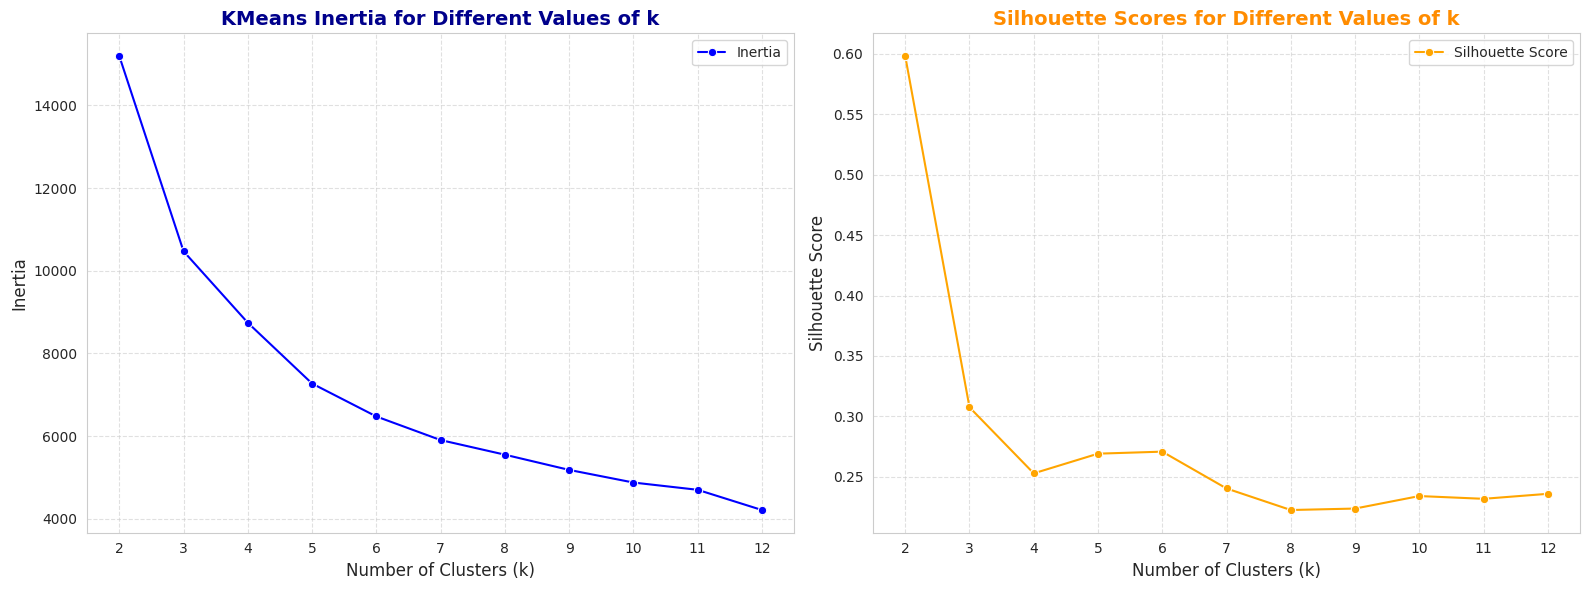

In [100]:
# --- KMeans evaluation ---
max_k = 12
inertia = []
silhouette_scores = []
k_values = range(2, max_k + 1)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, max_iter=1000)
    cluster_labels = kmeans.fit_predict(X_scaled)

    sil_score = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(sil_score)
    inertia.append(kmeans.inertia_)

# --- Plot results ---
sns.set_style("whitegrid")
sns.set_palette("muted")

plt.figure(figsize=(16, 6))

# Elbow (Inertia) plot
plt.subplot(1, 2, 1)
sns.lineplot(x=k_values, y=inertia, marker='o', color='blue', label='Inertia')
plt.title('KMeans Inertia for Different Values of k', fontsize=14, fontweight='bold', color='darkblue')
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia', fontsize=12)
plt.xticks(k_values, fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=10)

# Silhouette plot
plt.subplot(1, 2, 2)
sns.lineplot(x=k_values, y=silhouette_scores, marker='o', color='orange', label='Silhouette Score')
plt.title('Silhouette Scores for Different Values of k', fontsize=14, fontweight='bold', color='darkorange')
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.xticks(k_values, fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=10)

plt.tight_layout()
plt.show()


In [101]:
from sklearn.cluster import KMeans

# Fit KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
segm_df['segment'] = kmeans.fit_predict(X_scaled)


#### Cluster Summary

| **Segment** | **Cluster Name**             | **Key Traits**                                                          | **Business Interpretation**                                                                                                |
| ----------- | ---------------------------- | ----------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------------------------------- |
| **0**       | **Mid-Value Customers**      | Moderate frequency, medium CLV, very high probability_alive             | Consistent and reliable buyers who purchase often enough to be valuable. Focus on nurturing loyalty and gradual upselling. |
| **1**       | **Occasional Buyers**        | Low frequency, lowest CLV, lower probability_alive                      | Low engagement group with small purchases and inconsistent activity. Target with reactivation or win-back offers.          |
| **2**       | **VIP High-Value Customers** | Very high frequency, extremely high spend per purchase, high CLV, loyal | Top-tier customers with large order sizes and strong retention signals. Prioritize retention, exclusivity, and advocacy.   |

---

**Behavioural Highlight per Segment**

| **Segment**                              | **Description**                           | **Behavioral Highlights**                                                                                                                                                                                                                                                                                                                        |
| ---------------------------------------- | ----------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| **Cluster 0 — Mid-Value Customers**      | **Frequent and loyal mid-range spenders** | • Buy fairly often (**~5.1 purchases**) <br>• Very recent activity (**recency ≈ 30 weeks**, **tenure ≈ 35 weeks**) <br>• Very high probability of being alive (**0.98**) <br>• Moderate predicted CLV (**≈ 22.8**) <br>• **Average spend per purchase (~₱380)** <br>• Stable, reliable customer base that can be grown with personalized offers. |
| **Cluster 1 — Occasional Buyers**        | **Low-engagement, low-value group**       | • Few purchases (**~1.4**) <br>• Shorter lifecycle (**tenure ≈ 25 weeks**) <br>• Lower alive probability (**0.78**) <br>• Lowest CLV (**≈ 13.2**) <br>• **High recency ratio (0.51)** → have not purchased recently <br>• Inactive or churn-risk group; best suited for reactivation campaigns.                                                  |
| **Cluster 2 — VIP High-Value Customers** | **High-frequency, high-value loyalists**  | • Very frequent (**~9.4 purchases**) <br>• Long-tenured (**~37 weeks**) <br>• High alive probability (**0.97**) <br>• **Extremely high CLV (~219)** <br>• **Large average spend (~₱1,015)** and **value per purchase (~₱38)** <br>• Stable and premium customers — ideal for retention, loyalty programs, and exclusives.                        |


In [102]:
cluster_summary = segm_df.groupby('segment').agg({
    'frequency': 'mean',
    'recency': 'mean',
    'tenure': 'mean',
    'predicted_purchases': 'mean',
    'monetary_value': 'mean',
    'prob_alive': 'mean',
    'predicted_clv_xgb': ['mean', 'sum', 'count'],
    'log_predicted_clv_xgb': 'mean',
    'value_per_purchase': 'mean',
    'recency_ratio': 'mean'
}).round(2)

# Flatten multi-level columns
cluster_summary.columns = [
    '_'.join(col).strip() if isinstance(col, tuple) else col
    for col in cluster_summary.columns
]

cluster_summary = cluster_summary.reset_index()
cluster_summary


,segment,frequency_mean,recency_mean,tenure_mean,predicted_purchases_mean,monetary_value_mean,prob_alive_mean,predicted_clv_xgb_mean,predicted_clv_xgb_sum,predicted_clv_xgb_count,log_predicted_clv_xgb_mean,value_per_purchase_mean,recency_ratio_mean
0,0,5.11,30.42,34.65,1.64,379.85,0.98,22.830000,23861.230469,1045,3.10,4.77,0.88
1,1,1.37,12.11,25.39,0.88,305.80,0.78,13.170000,11496.299805,873,2.60,5.80,0.51
2,2,9.43,33.28,36.75,2.40,1015.47,0.97,219.020004,15112.219727,69,5.25,38.14,0.90


In [103]:
# Define descriptive segment names
segment_names = {
    0: "Mid-Value Customers",
    1: "Occasional Buyers",
    2: "VIP High-Value Customers"
}

# Map segment IDs to names
segm_df['segment_name'] = segm_df['segment'].map(segment_names)

In [104]:
cluster_summary['segment_name'] = cluster_summary['segment'].map(segment_names)

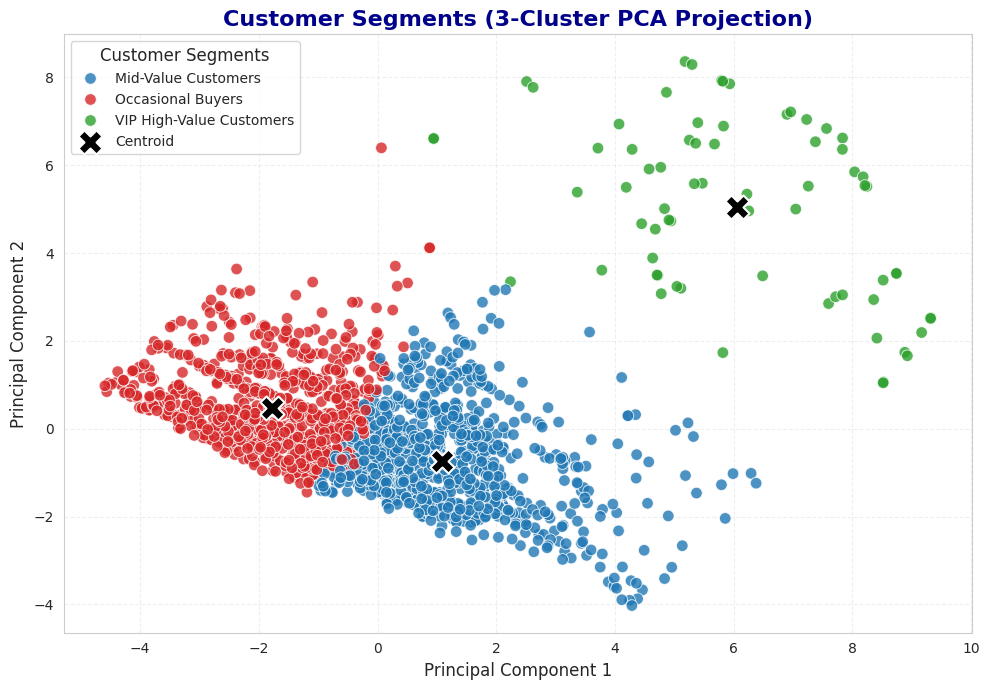

In [105]:
# Assuming X_scaled is the scaled segm_features
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(X_scaled)
segm_df['PCA1'] = pca_result[:, 0]
segm_df['PCA2'] = pca_result[:, 1]

# Color palette
palette = {
    "Mid-Value Customers": "#1f77b4",
    "Occasional Buyers": "#d62728",
    "VIP High-Value Customers": "#2ca02c"
}

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=segm_df,
    x='PCA1',
    y='PCA2',
    hue='segment_name',
    palette=palette,
    s=70,
    alpha=0.8,
    edgecolor='white'
)

# Add centroids
centroids = segm_df.groupby('segment_name')[['PCA1', 'PCA2']].mean()
plt.scatter(
    centroids['PCA1'], centroids['PCA2'],
    s=300, c='black', marker='X', edgecolors='white', linewidths=1.5, label='Centroid'
)

plt.title("Customer Segments (3-Cluster PCA Projection)", fontsize=16, fontweight='bold', color='darkblue')
plt.xlabel("Principal Component 1", fontsize=12)
plt.ylabel("Principal Component 2", fontsize=12)
plt.legend(title='Customer Segments', title_fontsize=12, fontsize=10, loc='best', frameon=True)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


In [113]:
from plotly import graph_objects as go
import numpy as np

# --- Updated color palette for consistency with radar plot ---
colors = {
    "Mid-Value Customers": 'teal',
    "Occasional Buyers": 'lightcoral',
    "VIP High-Value Customers": 'gold'
}

# Make sure segm_df['segment_name'] matches new labels
segm_df['segment_name'] = segm_df['segment_name'].replace({
    "Low-Value Occasional Buyers": "Occasional Buyers",
    "VIP Power Buyers": "VIP High-Value Customers"
})

# Features to show in hover
hover_cols = ['frequency', 'recency', 'tenure', 'monetary_value', 'prob_alive', 'predicted_purchases']

fig_pca = go.Figure()

# --- Scatter points per segment ---
for segment in segm_df['segment_name'].unique():
    color = colors.get(segment, 'gray')  # default gray if not in colors
    seg_data = segm_df[segm_df['segment_name'] == segment].reset_index(drop=True)

    # Build hover text per row
    hover_text = []
    for i in range(len(seg_data)):
        text_lines = []
        for col in hover_cols:
            val = seg_data.loc[i, col]
            if np.issubdtype(type(val), np.number):
                text_lines.append(f"{col}: {val:,.2f}")
            else:
                text_lines.append(f"{col}: {val}")
        hover_text.append("<br>".join(text_lines))

    fig_pca.add_trace(go.Scatter(
        x=seg_data['PCA1'],
        y=seg_data['PCA2'],
        mode='markers',
        name=segment,
        marker=dict(size=10, color=color, line=dict(width=1, color='white'), opacity=0.8),
        hovertemplate='%{text}<extra></extra>',
        text=hover_text
    ))

# --- Centroids ---
centroids_xy = segm_df.groupby('segment_name')[['PCA1', 'PCA2']].mean()
fig_pca.add_trace(go.Scatter(
    x=centroids_xy['PCA1'],
    y=centroids_xy['PCA2'],
    mode='markers+text',
    name='Centroid',
    marker=dict(size=18, color='black', symbol='x', line=dict(width=2, color='white')),
    text=centroids_xy.index,
    textposition='top center',
    hovertemplate='Centroid<br>%{text}<extra></extra>'
))

# --- Layout ---
fig_pca.update_layout(
    title=dict(text="Customer Segments (PCA Projection)", x=0.5, font=dict(size=20)),
    xaxis_title="Principal Component 1",
    yaxis_title="Principal Component 2",
    template='plotly_white',
    width=1300,
    height=600,
    hovermode='closest'
)

fig_pca.show()


### Recommendation System

This sections goal is to build a scalable, interpretable recommendation system to support cross-selling, personalization, and merchandising strategy.

---

**Methodology**

1. Apriori-Based Association Rules
- Constructed a basket matrix of invoices vs. products using one-hot encoding.
- Applied the Apriori algorithm to identify frequent itemsets and generate association rules.
- Extracted rules with high **confidence** and **lift** to capture strong co-purchase signals.

2. TF-IDF Content-Based Similarity
- Vectorized descriptions using **TF-IDF** to capture semantic meaning.
- Computed **cosine similarity** between products to identify textually similar items.
- Enabled recommendations even for **cold-start products** with no purchase history.


3. Hybrid Recommendation Function
- Combined Apriori and TF-IDF outputs using set union logic.
- Returned top-N recommendations with product descriptions.
- Balanced behavioral and semantic signals for robust suggestions.

---

**Comparative Evaluation:**

| Method        | Signal Type       | Strengths                              | Limitations                          |
|---------------|-------------------|----------------------------------------|--------------------------------------|
| Apriori-only  | Behavioral         | Interpretable, grounded in transactions| Sparse for niche or new products     |
| TF-IDF-only   | Semantic (content) | Cold-start friendly, description-aware | Ignores actual purchase behavior     |
| Hybrid        | Combined           | Broad coverage, robust recommendations | No ranking by source strength        |

---

**Business Impact:**
- Enables **personalized product suggestions** at checkout or via CRM campaigns.
- Supports **cross-sell strategy** by surfacing frequently co-purchased items.
- Improves **customer experience** by recommending visually or thematically similar products.


#### FP Growth

In [ ]:
# Ensure all StockCodes are strings without spaces
df['StockCode'] = df['StockCode'].astype(str).str.strip()

In [ ]:
item_counts = df['StockCode'].value_counts()
popular_items = item_counts[item_counts > 50].index
df_filtered = df[df['StockCode'].isin(popular_items)]

In [ ]:
# Create basket: one-hot encoding per invoice
basket = (df_filtered.groupby(['InvoiceNo', 'StockCode'])['Quantity']
          .sum().unstack().reset_index().fillna(0)
          .set_index('InvoiceNo'))

# Convert to 1/0
basket_sets = basket.applymap(lambda x: 1 if x > 0 else 0)
basket_sets = basket_sets.astype(bool)
basket_sets.head(3)

StockCode,10125,10133,10135,11001,15034,15036,15039,15044A,15044C,15044D,15056BL,15056N,15056P,15058A,15060B,16008,16014,16016,16045,16156S,16161P,16161U,16169E,16225,16235,16236,16237,16238,17003,17021,17091J,18097C,20658,20665,20668,20674,20675,20676,20677,20679,20682,20685,20686,20711,20712,20713,20717,20718,20719,20723,20724,20725,20726,20727,20728,20749,20750,20751,20752,20754,20761,20762,20764,20765,20767,20801,20828,20829,20832,20846,20886,20914,20956,20961,20963,20967,20969,20970,20971,20972,20973,20974,20975,20977,20978,20979,20981,20982,20983,20984,20985,20986,20992,20996,21012,21014,21015,21033,21034,21035,21039,21041,21042,21043,21055,21056,21058,21059,21060,21061,21062,21063,21064,21068,21069,21070,21071,21078,21080,21084,21086,21088,21090,21094,21096,21098,21107,21108,21109,21110,21111,21114,21115,21116,21121,21122,21123,21124,21125,21126,21135,21136,21137,21154,21155,21156,21158,21159,21162,21163,21164,21165,21166,21169,21171,21172,21174,21175,21179,21181,21201,21204,21205,21206,21207,21208,21209,21210,21211,21212,21213,21215,21216,21217,21218,21224,21231,21232,21238,21239,21240,21242,21243,21244,21245,21248,21249,21257,21258,21259,21260,21272,21287,21294,21313,21314,21326,21327,21328,21329,21340,21354,21355,21356,21358,21361,21363,21380,21381,21382,21383,21385,21389,21390,21391,21394,21395,21399,21401,21402,21403,21407,21408,21411,21428,21429,21430,21439,21446,21447,21448,21452,21462,21463,21464,21465,21466,21467,21469,21470,21471,21479,21481,21484,21485,21494,21495,21497,21498,21499,21500,21504,21506,21507,21508,21509,21519,21523,21524,21527,21528,21530,21531,21533,21534,21535,21537,21539,21544,21557,21558,21559,21561,21563,21564,21577,21578,21584,21586,21588,21591,21592,21609,21615,21616,21617,21618,21619,21620,21621,21622,21623,21624,21625,21626,21636,21640,21642,21650,21658,21668,21669,21670,21671,21672,21673,21675,21677,21679,21680,21700,21703,21704,21705,21706,21713,21714,21715,21716,21718,21724,21730,21731,21733,21735,21742,21744,21745,21746,21749,21754,21755,21756,21770,21773,21774,21781,21786,21787,21788,21789,21790,21791,21792,21793,21794,21809,21810,21811,21817,21818,21819,21820,21822,21823,21824,21828,21829,21830,21832,21833,21843,21844,21845,21864,21865,21866,21867,21868,21870,21871,21872,21873,21874,21875,21876,21877,21878,21879,21880,21883,21888,21889,21890,21891,21892,21894,21896,21899,21900,21901,21902,21903,21905,21906,21907,21908,21912,21913,21914,21915,21916,21917,21918,21922,21925,21926,21927,21928,21929,21930,21931,21932,21933,21934,21935,21936,21937,21947,21948,21949,21955,21967,21974,21975,21976,21977,21980,21981,21982,21983,21984,21985,21986,21987,21988,21989,21990,21991,21992,21993,22021,22023,22024,22025,22026,22027,22028,22029,22030,22035,22037,22041,22045,22046,22047,22055,22057,22059,22061,22062,22063,22064,22065,22066,22068,22070,22071,22072,22074,22075,22076,22077,22078,22079,22080,22081,22082,22083,22084,22085,22086,22087,22088,22089,22090,22091,22092,22093,22094,22095,22096,22097,22098,22099,22107,22109,22110,22111,22112,22113,22114,22115,22116,22117,22118,22119,22120,22121,22123,22128,22130,22131,22132,22133,22134,22136,22138,22139,22141,22142,22144,22147,22148,22149,22150,22151,22152,22153,22154,22155,22156,22158,22161,22163,22167,22168,22169,22170,22171,22173,22174,22175,22176,22178,22179,22180,22185,22186,22187,22188,22189,22190,22191,22192,22193,22195,22196,22197,22198,22199,22200,22203,22207,22208,22209,22210,22211,22212,22215,22217,22219,22220,22222,22224,22227,22228,22229,22230,22231,22232,22233,22236,22241,22243,22244,22245,22247,22249,22250,22251,22252,22261,22262,22265,22266,22267,22268,22269,22271,22273,22274,22276,22277,22278,22282,22283,22284,22285,22286,22287,22291,22292,22293,22294,22295,22296,22297,22300,22301,22302,22303,22306,22307,22309,22310,22311,22312,22313,22314,22315,22318,22319,22320,22321,22325,22326,22327,22328,22329,22331,22332,22333,22334,22335,22336,22338,22339,22340,22342,22343,22348,22349,22350,22352,22354,22355,22356,22357,22358,22359,22360,223

In [ ]:
# FP-Growth (much faster than Apriori)
frequent_itemsets = fpgrowth(basket_sets, min_support=0.003, use_colnames=True)

# Generate association rules
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
rules = rules.sort_values('confidence', ascending=False)

print("Top 5 FP-Growth rules:")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head())


Top 5 FP-Growth rules:
                                antecedents consequents   support  confidence  \
111262         (23173, 22698, 23172, 23170)     (22699)  0.003000         1.0   
109618         (23174, 22697, 23172, 23170)     (23171)  0.003437         1.0   
109679  (23174, 23172, 23170, 22697, 22699)     (23171)  0.003273         1.0   
106234         (23173, 22698, 23171, 23170)     (22699)  0.003273         1.0   
110860         (23173, 22697, 23172, 23170)     (23171)  0.003109         1.0   

             lift  
111262  23.411239  
109618  67.892593  
109679  67.892593  
106234  23.411239  
110860  67.892593  


“When customers buy products 22699 and 22698 together, there’s an 89.4% chance they’ll also buy 22697 — and this pattern is 24× stronger than random.”

In [ ]:
def fpgrowth_recommend(product_id, top_n=5):
    product_id = str(product_id).strip()

    # Find rules where this product is in the antecedents
    fpgrowth_recs = rules[rules['antecedents'].apply(lambda x: product_id in map(str, x))]

    # Extract all consequents (recommended items)
    fpgrowth_items = set()
    for cons in fpgrowth_recs['consequents']:
        fpgrowth_items.update(map(str, cons))
    fpgrowth_items.discard(product_id)

    fpgrowth_items = list(fpgrowth_items)[:top_n]
    return [(item, product_desc.loc[item]['Description']) for item in fpgrowth_items if item in product_desc.index]


In [ ]:
product_id = df_filtered['StockCode'].iloc[15]

# Aggregate descriptions by product
product_desc = df[['StockCode','Description']].drop_duplicates().set_index('StockCode')

# Get first matching description
desc = product_desc.loc[product_id]
desc_text = desc.iloc[0] if isinstance(desc, pd.Series) else desc

In [ ]:
# FPGrowth
fpgrowth_df = pd.DataFrame(fpgrowth_recommend(product_id, 5), columns=['StockCode', 'Description'])
print("FP Growth Recommendations:")
print(f"Product ID {product_id} ({desc_text}):")
print("")
display(fpgrowth_df)

FP Growth Recommendations:
Product ID 22623 (BOX OF VINTAGE JIGSAW BLOCKS ):



,StockCode,Description
0,21790,VINTAGE SNAP CARDS
1,22622,BOX OF VINTAGE ALPHABET BLOCKS
2,21889,WOODEN BOX OF DOMINOES


#### TF-IDF

In [ ]:
# Vectorize descriptions
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(product_desc['Description'])

# Compute cosine similarity
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
cosine_sim_df = pd.DataFrame(cosine_sim, index=product_desc.index, columns=product_desc.index)
cosine_sim_df.index = cosine_sim_df.index.astype(str).str.strip()
cosine_sim_df.columns = cosine_sim_df.columns.astype(str).str.strip()

print("Cosine Similarity:")
cosine_sim_df.head()


Cosine Similarity:


StockCode    85123A     71053  84406B  84029G    84029E  22752     21730  \
StockCode                                                                  
85123A     1.000000  0.216744     0.0     0.0  0.239788    0.0  0.345982   
71053      0.216744  1.000000     0.0     0.0  0.151257    0.0  0.000000   
84406B     0.000000  0.000000     1.0     0.0  0.000000    0.0  0.000000   
84029G     0.000000  0.000000     0.0     1.0  0.000000    0.0  0.000000   
84029E     0.239788  0.151257     0.0     0.0  1.000000    0.0  0.000000   

StockCode     22633     22632  84879  22745  22748  22749     22310  84969  \
StockCode                                                                    
85123A     0.000000  0.000000    0.0    0.0    0.0    0.0  0.000000    0.0   
71053      0.000000  0.000000    0.0    0.0    0.0    0.0  0.000000    0.0   
84406B     0.000000  0.000000    0.0    0.0    0.0    0.0  0.000000    0.0   
84029G     0.186219  0.000000    0.0    0.0    0.0    0.0  0.275404    0.0   
84029E     0.000000  0.075763    0.0    0.0    0.0    0.0  0.000000    0.0   

StockCode  22623  22622  21754  21755     21777  48187  22960     22913  \
StockCode                                                                 
85123A       0.0    0.0    0.0    0.0  0.142508    0.0    0.0  0.000000   
71053        0.0    0.0    0.0    0.0  0.228154    0.0    0.0  0.000000   
84406B       0.0    0.0    0.0    0.0  0.000000    0.0    0.0  0.228105   
84029G       0.0    0.0    0.0    0.0  0.000000    0.0    0.0  0.000000   
84029E       0.0    0.0    0.0    0.0  0.099451    0.0    0.0  0.074863   

StockCode     22912     22914  21756  22728     22727  22726  21724  21883  \
StockCode                                                                    
85123A     0.000000  0.000000    0.0    0.0  0.000000    0.0    0.0    0.0   
71053      0.000000  0.000000    0.0    0.0  0.000000    0.0    0.0    0.0   
84406B     0.218168  0.228604    0.0    0.0  0.000000    0.0    0.0    0.0   
84029G     0.000000  0.000000    0.0    0.0  0.000000    0.0    0.0    0.0   
84029E     0.000000  0.000000    0.0    0.0  0.091406    0.0    0.0    0.0   

StockCode  10002  21791     21035  22326  22629  22659  22631  22661  \
StockCode                                                              
85123A       0.0    0.0  0.000000    0.0    0.0    0.0    0.0    0.0   
71053        0.0    0.0  0.000000    0.0    0.0    0.0    0.0    0.0   
84406B       0.0    0.0  0.000000    0.0    0.0    0.0    0.0    0.0   
84029G       0.0    0.0  0.000000    0.0    0.0    0.0    0.0    0.0   
84029E       0.0    0.0  0.098913    0.0    0.0    0.0    0.0    0.0   

StockCode     21731  22900  21913  22540  22544  22492  POST  22086     20679  \
StockCode                                                                       
85123A     0.151223    0.0    0.0    0.0    0.0    0.0   0.0    0.0  0.000000   
71053      0.000000    0.0    0.0    0.0    0.0    0.0   0.0    0.0  0.000000   
84406B     0.000000    0.0    0.0    0.0    0.0    0.0   0.0    0.0  0.000000   
84029G     0.000000    0.0    0.0    0.0    0.0    0.0   0.0    0.0  0.000000   
84029E     0.080258    0.0    0.0    0.0    0.0    0.0   0.0    0.0  0.111153   

StockCode  37370  21871  21071  21068     82483     82486     82482    82494L  \
StockCode                                                                       
85123A       0.0    0.0    0.0    0.0  0.141796  0.137309  0.141844  0.181050   
71053        0.0    0.0    0.0    0.0  0.159872  0.154813  0.159927  0.204131   
84406B       0.0    0.0    0.0    0.0  0.000000  0.000000  0.000000  0.000000   
84029G       0.0    0.0    0.0    0.0  0.000000  0.000000  0.000000  0.000000   
84029E       0.0    0.0    0.0    0.0  0.098954  0.095822  0.098988  0.126348   

StockCode  21258     22114     21733  22386    85099C  21033  20723   84997B  \
StockCode                                                                      
85123A       0.0  0.000000  0.819107    0.0  0

In [ ]:
def tfidf_recommend(product_id, top_n=5):
    product_id = str(product_id).strip()
    if product_id in cosine_sim_df.index:
        sim_scores = cosine_sim_df.loc[product_id]
        if isinstance(sim_scores, pd.DataFrame):
            sim_scores = sim_scores.squeeze(axis=0)
        if isinstance(sim_scores, pd.Series):
            sim_scores = sim_scores.sort_values(ascending=False)
            tfidf_items = set(sim_scores.index[1:top_n+1])
        else:
            tfidf_items = set()
    else:
        tfidf_items = set()
    return [(item, product_desc.loc[item]['Description']) for item in tfidf_items if item in product_desc.index]


In [ ]:
# TF-IDF-only
tfidf_df = pd.DataFrame(tfidf_recommend(product_id, 5), columns=['StockCode', 'Description'])
print("TF-IDF-only Recommendations:")
print(f"Product ID {product_id} ({desc_text}):")
print("")
display(tfidf_df)

TF-IDF-only Recommendations:
Product ID 22623 (BOX OF VINTAGE JIGSAW BLOCKS ):



,StockCode,Description
0,21913,VINTAGE SEASIDE JIGSAW PUZZLES
1,22544,MINI JIGSAW SPACEBOY
2,22622,BOX OF VINTAGE ALPHABET BLOCKS
3,22230,JIGSAW TREE WITH WATERING CAN
4,22547,MINI JIGSAW DINOSAUR


#### Hybrid

In [ ]:
def hybrid_recommend(product_id, top_n=5):
    product_id = str(product_id).strip()

    # --- FP-Growth part ---
    fpgrowth_recs = rules[rules['antecedents'].apply(lambda x: product_id in map(str, x))]
    fpgrowth_items = set()
    for cons in fpgrowth_recs['consequents']:
        fpgrowth_items.update(map(str, cons))
    fpgrowth_items.discard(product_id)

    # --- TF-IDF part ---
    tfidf_items = set()
    if product_id in cosine_sim_df.index:
        idx = cosine_sim_df.index.get_loc(product_id)
        sim_scores = list(enumerate(cosine_sim_df.iloc[idx]))
        sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
        for i, _ in sim_scores[1:top_n+1]:
            tfidf_items.add(cosine_sim_df.index[i])

    # --- Combine (union) ---
    hybrid_items = list(fpgrowth_items.union(tfidf_items))[:top_n]

    return [(item, product_desc.loc[item]['Description'])
            for item in hybrid_items if item in product_desc.index]


In [ ]:
# Get first matching description
desc = product_desc.loc[product_id]
desc_text = desc.iloc[0] if isinstance(desc, pd.Series) else desc

# Get recommendations
recommendations = hybrid_recommend(product_id, 5)

# Convert to DataFrame
rec_df = pd.DataFrame(recommendations, columns=['StockCode', 'Description'])

# Display header and table
print("Hybrid Recommendations:")
print(f"Product ID {product_id} ({desc_text}):")
display(rec_df)



Hybrid Recommendations:
Product ID 22623 (BOX OF VINTAGE JIGSAW BLOCKS ):


,StockCode,Description
0,21913,VINTAGE SEASIDE JIGSAW PUZZLES
1,21889,WOODEN BOX OF DOMINOES
2,21790,VINTAGE SNAP CARDS
3,22544,MINI JIGSAW SPACEBOY
4,22622,BOX OF VINTAGE ALPHABET BLOCKS


In [ ]:
# Get first matching description
desc = product_desc.loc[product_id]
desc_text = desc.iloc[0] if isinstance(desc, pd.Series) else desc

# Generate recommendations
fpgrowth_df = pd.DataFrame(fpgrowth_recommend(product_id, 5), columns=['StockCode', 'Description'])
tfidf_df = pd.DataFrame(tfidf_recommend(product_id, 5), columns=['StockCode', 'Description'])
hybrid_df = pd.DataFrame(hybrid_recommend(product_id, 5), columns=['StockCode', 'Description'])

# Add source labels
fpgrowth_df['Source'] = 'FP-Growth'
tfidf_df['Source'] = 'TF-IDF'
hybrid_df['Source'] = 'Hybrid'

# Combine and deduplicate
comparison_df = pd.concat([fpgrowth_df, tfidf_df, hybrid_df]).drop_duplicates().reset_index(drop=True)

# Display
print(f"🔍 Recommendation Comparison for Product {product_id} ({desc_text})")
display(comparison_df)


🔍 Recommendation Comparison for Product 22623 (BOX OF VINTAGE JIGSAW BLOCKS )


,StockCode,Description,Source
0,21790,VINTAGE SNAP CARDS,FP-Growth
1,22622,BOX OF VINTAGE ALPHABET BLOCKS,FP-Growth
2,21889,WOODEN BOX OF DOMINOES,FP-Growth
3,21913,VINTAGE SEASIDE JIGSAW PUZZLES,TF-IDF
4,22544,MINI JIGSAW SPACEBOY,TF-IDF
5,22622,BOX OF VINTAGE ALPHABET BLOCKS,TF-IDF
6,22230,JIGSAW TREE WITH WATERING CAN,TF-IDF
7,22547,MINI JIGSAW DINOSAUR,TF-IDF
8,21913,VINTAGE SEASIDE JIGSAW PUZZLES,Hybrid
9,21889,WOODEN BOX OF DOMINOES,Hybrid


### Dashboard Layout

In [126]:
import plotly.graph_objects as go

# --- Cluster summary data ---
cluster_summary_data = {
    'Segment': [0, 1, 2],
    'Cluster Name': ["Mid-Value Customers", "Occasional Buyers", "VIP High-Value Customers"],
    'Frequency (avg)': [5.11, 1.37, 9.43],
    'Recency (weeks)': [30.42, 12.11, 33.28],
    'Tenure (weeks)': [34.65, 25.39, 36.75],
    'Predicted Purchases (avg)': [1.64, 0.88, 2.40],
    'Monetary Value (avg)': [379.85, 305.80, 1015.47],
    'Prob Alive': [0.98, 0.78, 0.97],
    'Predicted CLV (XGB)': [22.83, 13.17, 219.02],
    'Value per Purchase': [4.77, 5.80, 38.14],
    'Recency Ratio': [0.88, 0.51, 0.90]
}

# --- Colors ---
header_color = '#457B9D'       # bluish-grey
cell_color = '#E0F2F1'         # light pastel blue/green
line_color = 'white'            # cell borders

# --- Create Plotly Table ---
fig_table = go.Figure(data=[go.Table(
    header=dict(
        values=list(cluster_summary_data.keys()),
        fill_color=header_color,
        font=dict(color='white', size=16, family="Arial Bold"),
        align='center',
        line_color=line_color
    ),
    cells=dict(
        values=[cluster_summary_data[col] for col in cluster_summary_data.keys()],
        fill_color=cell_color,
        font=dict(color='black', size=14, family="Arial"),
        align='center',
        line_color=line_color
    )
)])

# --- Layout ---
fig_table.update_layout(
    title=dict(
        text="Customer Segmentation",
        font=dict(size=20, color='black')
    ),
    width=1300,
    height=450,
    margin=dict(t=80)
)

fig_table.show()


In [122]:
# --- Metrics to visualize ---
metrics = [
    'frequency_mean',
    'recency_mean',
    'recency_ratio_mean',
    'monetary_value_mean',
    'value_per_purchase_mean'
]

# --- Normalize metrics for radar scaling ---
cluster_norm = cluster_summary.copy()
for col in metrics:
    cluster_norm[col + '_norm'] = cluster_norm[col] / cluster_norm[col].max()

# --- Create radar subplot figure with space for titles ---
fig_radar = make_subplots(
    rows=1, cols=3,
    specs=[[{'type':'polar'}, {'type':'polar'}, {'type':'polar'}]],
    subplot_titles=segm_df.groupby('segment')['segment_name'].first().tolist(),
    horizontal_spacing=0.1  # add some horizontal spacing between radars
)

colors = ['teal', 'lightcoral', 'gold']

# --- Add each cluster as a radar ---
for i, row in cluster_norm.iterrows():
    fig_radar.add_trace(
        go.Scatterpolar(
            r=row[[m + '_norm' for m in metrics]].values,
            theta=[m.replace('_mean','').replace('_',' ').title() for m in metrics],
            fill='toself',
            line=dict(color=colors[i], width=2),
            opacity=0.6,
            name=row['segment'],
            hovertemplate='<b>%{text}</b><extra></extra>',
            text=[f'{m.replace("_mean","").replace("_"," ").title()}: {row[m]:,.2f}' for m in metrics]
        ),
        row=1, col=i+1
    )

# --- Layout ---
fig_radar.update_layout(
    title=dict(text="Cluster Profiles", font=dict(size=20)),
    template='plotly_white',
    height=500,
    width=1300,
    showlegend=False
)

# --- Increase vertical space for subplot titles ---
for i in range(1, 4):
    fig_radar.layout[f'polar{i}'].domain.y = [0, 0.85]  # leave 15% space above for titles

fig_radar.show()


In [127]:
kpi_fig.show()
sales_trend_fig.show()
fig_combined_top10.show()
monthly_fig.show()
top10_fig_treemap.show()
fig_combined.show()
cancellation_monthly_fig.show()
cancelled_fig_tree.show()
fig_table.show()
fig_radar.show()
fig_pca.show()